In [140]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize, lsq_linear
from scipy.special import expit
from sklearn.model_selection import KFold

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline

from scipy.spatial import cKDTree

MODEL_NAME = 'SE-Hurdle-S'
MODEL_TAG = 'self_exciting_hurdle_s_vs_hurdle_ar1'

SEED = 63
EPS = 0.49
Y = 20

SELF_RESIDUAL_DIST = 'normal' 
HURDLE_RESIDUAL_DIST = 'normal'
CONSTRAIN_EXCITATION = True
HURDLE_NAME = 'Hurdle-AR(1)-S'

RHO_GRID = np.linspace(0.0, 0.98, 51)
N_SPLITS = 5
N_SIM = 10000
N_RANK_REPS = 200
N_BOOT = 1000
DPI = 300

TASK_ROOT = Path.cwd().parent
OUTPUT = TASK_ROOT/'output'
RESULT_DIR = OUTPUT / 'results'
FIG_DIR = OUTPUT/'figures'
DATA = TASK_ROOT/'input'


In [141]:
raw = pd.read_csv(DATA/'df_traj_all.csv')

raw['CareerAgeZero'] = pd.to_numeric(raw['CareerAgeZero'], errors='coerce')
raw['pubs_adj'] = pd.to_numeric(raw['pubs_adj'], errors='coerce').clip(lower=0)
raw = raw.dropna(subset=['dblp_id', 'CareerAgeZero', 'pubs_adj'])

full_ids = (raw.groupby('dblp_id')['CareerAgeZero'].max().loc[lambda s: s.eq(Y)].index)

prepared = raw[raw['dblp_id'].isin(full_ids)].copy()
prepared = (prepared.groupby(['dblp_id', 'CareerAgeZero'], as_index=False)['pubs_adj'].sum())

panel = ( prepared.pivot(index='dblp_id', columns='CareerAgeZero', values='pubs_adj').reindex(columns=np.arange(Y + 1)).sort_index())

missing_person_years = int(panel.isna().sum().sum())
panel = panel.fillna(0.0)

Q_EMP = panel.to_numpy(dtype=float)
EMP_IDS = panel.index.to_numpy()
N_EMP = Q_EMP.shape[0]


In [142]:
STAGE_ORDER = ['0', '1-4', '5-7', '8-20']
STAGE_TRANSITIONS = {
    '0': np.array([0]),
    '1-4': np.arange(1, 5),
    '5-7': np.arange(5, 8),
    '8-20': np.arange(8, 20)}

def transition_stage(t):
    if t == 0:
        return '0'
    if 1 <= t <= 4:
        return '1-4'
    if 5 <= t <= 7:
        return '5-7'
    if 8 <= t <= 19:
        return '8-20'
    raise ValueError(f'No stage for transition year {t}')

def target_stage(target_year):
    return transition_stage(target_year - 1)

def history_panel(q, rho):
    n, years = q.shape
    history = np.zeros_like(q, dtype=float)
    numerator = np.zeros(n)
    denominator = np.zeros(n)

    for target_year in range(1, years):
        history[:, target_year] = np.divide(numerator,denominator,out=np.zeros_like(numerator),where=denominator > 0)
        current_year = target_year - 1
        numerator = rho * numerator + np.log1p(q[:, current_year])
        denominator = rho * denominator + 1.0

    return history

def build_transition_rows(q, history):
    rows = []

    for target_year in range(1, q.shape[1]):
        transition_year = target_year - 1
        q_prev = q[:, transition_year]
        q_now = q[:, target_year]

        rows.append(pd.DataFrame({
            'scholar': np.arange(q.shape[0]),
            'transition_year': transition_year,'target_year': target_year,
            'stage': transition_stage(transition_year),
            'q_prev': q_prev,'q': q_now,
            'active': (q_now > 0).astype(int),
            'x_prev': np.log1p(q_prev),
            'prev_active': (q_prev > 0).astype(int),
            'restart': (q_prev <= 0).astype(int),
            'history': history[:, target_year]}))

    return pd.concat(rows, ignore_index=True)

In [143]:
CONTINUOUS = {'x_prev', 'history'}
RIDGE = 1e-6
MIN_PROB = 1e-9

def fit_scaler(data, feature_names):
    means = {}
    scales = {}

    for name in feature_names:
        if name in CONTINUOUS:
            means[name] = float(data[name].mean())
            scale = float(data[name].std(ddof=0))
            scales[name] = scale if np.isfinite(scale) and scale > 1e-8 else 1.0
        else:
            means[name] = 0.0
            scales[name] = 1.0

    return means, scales

def design_matrix(data, feature_names, means, scales):
    columns = [np.ones(len(data))]

    for name in feature_names:
        columns.append((data[name].to_numpy(dtype=float) - means[name]) / scales[name])

    return np.column_stack(columns)

def array_design(values, spec):
    n = len(next(iter(values.values())))
    columns = [np.ones(n)]

    for name in spec['feature_names']:
        columns.append((np.asarray(values[name], dtype=float) - spec['means'][name])/ spec['scales'][name])

    return np.column_stack(columns)

def fit_logistic(X, y, constrained_index=None):
    def objective(weights):
        eta = np.clip(X @ weights, -35, 35)
        p = expit(eta)
        nll = -np.sum(y * np.log(p + 1e-12)+ (1 - y) * np.log(1 - p + 1e-12))
        nll += RIDGE * np.sum(weights[1:] ** 2)

        gradient = X.T @ (p - y)
        gradient[1:] += 2 * RIDGE * weights[1:]
        return nll, gradient

    bounds = [(None, None)] * X.shape[1]
    if constrained_index is not None:
        bounds[constrained_index] = (0, None)

    result = minimize(objective,np.zeros(X.shape[1]),jac=True,method='L-BFGS-B',bounds=bounds)

    if not result.success:
        print(f'Logistic warning: {result.message}')

    return result.x

def fit_stage(stage_data, use_history=True, constrain_history=True):
    activity_features = ['x_prev', 'prev_active']
    positive_features = ['x_prev', 'restart']

    if use_history:
        activity_features.append('history')
        positive_features.append('history')

    act_means, act_scales = fit_scaler(stage_data, activity_features)
    X_act = design_matrix(stage_data, activity_features, act_means, act_scales)
    y_act = stage_data['active'].to_numpy(dtype=float)

    act_history_index = None
    if use_history and constrain_history:
        act_history_index = 1 + activity_features.index('history')

    activity_coef = fit_logistic(X_act,y_act,constrained_index=act_history_index)

    positive = stage_data[stage_data['active'].eq(1)].copy()
    pos_means, pos_scales = fit_scaler(positive, positive_features)
    X_pos = design_matrix(positive, positive_features, pos_means, pos_scales)
    y_pos = np.log(positive['q'].to_numpy(dtype=float))

    lower = np.full(X_pos.shape[1], -np.inf)
    upper = np.full(X_pos.shape[1], np.inf)

    if use_history and constrain_history:
        lower[1 + positive_features.index('history')] = 0.0

    positive_fit = lsq_linear(X_pos,y_pos,bounds=(lower, upper),lsq_solver='exact')

    positive_coef = positive_fit.x
    residuals = y_pos - X_pos @ positive_coef
    residuals = residuals - residuals.mean()
    sigma = max(float(np.sqrt(np.mean(residuals ** 2))), 1e-8)
    laplace_scale = max(float(np.mean(np.abs(residuals))), 1e-8)

    return {'activity': {
            'feature_names': activity_features,
            'means': act_means,
            'scales': act_scales,
            'coef': activity_coef,
            'n': len(stage_data)},
        'positive': {
            'feature_names': positive_features,
            'means': pos_means,
            'scales': pos_scales,
            'coef': positive_coef,
            'residuals': residuals,
            'sigma': sigma,
            'laplace_scale': laplace_scale,
            'n': len(positive)}}

def fit_model(q, history, use_history=True, constrain_history=True):
    rows = build_transition_rows(q, history)

    return {stage: fit_stage(rows[rows['stage'].eq(stage)],use_history=use_history,constrain_history=constrain_history) for stage in STAGE_ORDER}

def score_model(model, q, history):
    rows = build_transition_rows(q, history)
    nll = 0.0
    n = 0

    for stage in STAGE_ORDER:
        stage_data = rows[rows['stage'].eq(stage)]
        fitted = model[stage]

        X_act = design_matrix(stage_data,fitted['activity']['feature_names'],fitted['activity']['means'],fitted['activity']['scales'])
        p = np.clip(expit(X_act @ fitted['activity']['coef']),MIN_PROB,1 - MIN_PROB)
        y = stage_data['active'].to_numpy(dtype=float)
        nll -= np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        n += len(stage_data)

        positive = stage_data[stage_data['active'].eq(1)]
        X_pos = design_matrix(positive,fitted['positive']['feature_names'],fitted['positive']['means'],fitted['positive']['scales'])
        y_pos = np.log(positive['q'].to_numpy(dtype=float))
        sigma = fitted['positive']['sigma']
        standardized = (y_pos - X_pos @ fitted['positive']['coef']) / sigma

        nll += np.sum(0.5 * standardized ** 2+ np.log(sigma) + 0.5 * np.log(2 * np.pi))

    return nll / n

def original_scale_coefficients(spec):
    names = spec['feature_names']
    standardized = spec['coef']
    original = {'intercept': float(standardized[0])}

    for j, name in enumerate(names, start=1):
        original[name] = float(standardized[j] / spec['scales'][name])
        original['intercept'] -= (standardized[j]* spec['means'][name]/ spec['scales'][name])

    return original

def fit_hurdle_ar1(q):
    rows = build_transition_rows(q, np.zeros_like(q))
    fitted = {}

    for stage in STAGE_ORDER:
        d = rows[rows['stage'].eq(stage)].copy()
        transition_counts = np.zeros((2, 2), dtype=float)
        np.add.at(transition_counts,(d['prev_active'].to_numpy(dtype=int),d['active'].to_numpy(dtype=int)),1)
        transition_prob = transition_counts / transition_counts.sum(axis=1, keepdims=True)

        continuation = d[d['prev_active'].eq(1) & d['active'].eq(1)].copy()
        x = np.log(continuation['q_prev'].to_numpy(dtype=float))
        y = np.log(continuation['q'].to_numpy(dtype=float))
        X = np.column_stack([np.ones(len(y)), x])
        intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]
        residuals = y - intercept - beta * x
        residuals = residuals - residuals.mean()
        sigma = max(float(np.sqrt(np.mean(residuals ** 2))), 1e-8)
        laplace_scale = max(float(np.mean(np.abs(residuals))), 1e-8)

        restarts = d[d['prev_active'].eq(0) & d['active'].eq(1)]['q'].to_numpy(dtype=float)
        restart_scale = float(restarts.mean()) if len(restarts) else float(q[q > 0].mean())

        fitted[stage] = {
            'transition_counts': transition_counts,
            'transition_prob': transition_prob,
            'positive': {
                'intercept': float(intercept),'beta': float(beta),
                'residuals': residuals,
                'sigma': sigma,
                'laplace_scale': laplace_scale,
                'n': len(continuation)},
            'restart_scale': max(restart_scale, 1e-8),'restart_n': len(restarts)}

    q0 = q[:, 0]
    positive_q0 = q0[q0 > 0]
    fitted['initialization'] = {'p_active': float(np.mean(q0 > 0)),'positive_scale': float(positive_q0.mean())}

    return fitted

def score_hurdle_ar1(model, q):
    rows = build_transition_rows(q, np.zeros_like(q))
    nll = 0.0
    n = 0

    for stage in STAGE_ORDER:
        d = rows[rows['stage'].eq(stage)].copy()
        prev = d['prev_active'].to_numpy(dtype=int)
        active = d['active'].to_numpy(dtype=int)
        p = np.clip(model[stage]['transition_prob'][prev, active],MIN_PROB,1 - MIN_PROB)
        nll -= np.log(p).sum()
        n += len(d)

        continuation = d[(prev == 1) & (active == 1)]
        if len(continuation):
            x = np.log(continuation['q_prev'].to_numpy(dtype=float))
            y = np.log(continuation['q'].to_numpy(dtype=float))
            pos = model[stage]['positive']
            resid = y - pos['intercept'] - pos['beta'] * x
            sigma = pos['sigma']
            nll += np.sum(0.5 * (resid / sigma) ** 2+ np.log(sigma)+ 0.5 * np.log(2 * np.pi))

        restart = d[(prev == 0) & (active == 1)]['q'].to_numpy(dtype=float)
        if len(restart):
            scale = model[stage]['restart_scale']
            nll += np.sum(np.log(scale) + restart / scale)

    return nll / n

In [144]:
folds = list(KFold(n_splits=N_SPLITS,shuffle=True,random_state=SEED).split(Q_EMP))

hurdle_scores = []

for train_idx, test_idx in folds:
    hurdle_fold = fit_hurdle_ar1(Q_EMP[train_idx])
    hurdle_scores.append(
        score_hurdle_ar1(hurdle_fold,Q_EMP[test_idx]))

profile_rows = []

for rho in RHO_GRID:
    history = history_panel(Q_EMP, rho)
    scores = []

    for train_idx, test_idx in folds:
        fold_model = fit_model(Q_EMP[train_idx],history[train_idx],use_history=True,constrain_history=CONSTRAIN_EXCITATION)
        scores.append(score_model(fold_model,Q_EMP[test_idx],history[test_idx]))

    profile_rows.append({'rho': rho,'mean_nll': np.mean(scores),'se_nll': np.std(scores, ddof=1) / np.sqrt(len(scores))})

rho_profile = pd.DataFrame(profile_rows)
RHO_HAT = float(rho_profile.loc[rho_profile['mean_nll'].idxmin(), 'rho'])
HURDLE_CV_NLL = float(np.mean(hurdle_scores))
SELF_EXCITING_CV_NLL = float(rho_profile['mean_nll'].min())

if 0 < RHO_HAT < 1:
    HALF_LIFE = float(np.log(0.5) / np.log(RHO_HAT))
elif RHO_HAT == 0:
    HALF_LIFE = 0.0
else:
    HALF_LIFE = np.inf

rho_profile.to_csv(RESULT_DIR / 'rho_profile.csv', index=False)

print(f'fit rho: {RHO_HAT:.3f}')
print(f'mem halflife: {HALF_LIFE:.2f} years')
print(f'{HURDLE_NAME} cv nll: {HURDLE_CV_NLL:.4f}')
print(f'Self-exciting cv nll: {SELF_EXCITING_CV_NLL:.4f}')
print(f'cv improvement: {HURDLE_CV_NLL - SELF_EXCITING_CV_NLL:.4f}')

fit rho: 0.666
mem halflife: 1.71 years
Hurdle-AR(1)-S cv nll: 1.3527
Self-exciting cv nll: 1.0821
cv improvement: 0.2706


In [145]:
H_EMP = history_panel(Q_EMP, RHO_HAT)

hurdle_model = fit_hurdle_ar1(Q_EMP)
unrestricted_model = fit_model(Q_EMP,H_EMP,use_history=True,constrain_history=False)
self_exciting_model = fit_model(Q_EMP,H_EMP,use_history=True,constrain_history=True)

def parameter_table(model, model_label):
    rows = []

    for stage in STAGE_ORDER:
        for equation in ['activity', 'positive']:
            spec = model[stage][equation]
            original = original_scale_coefficients(spec)
            row = {'model': model_label,'stage': stage,'equation': equation,'n': spec['n'],**original}

            if equation == 'positive':
                row['sigma'] = spec['sigma']
                row['laplace_scale'] = spec['laplace_scale']
            rows.append(row)

    return pd.DataFrame(rows)

def hurdle_parameter_table(model):
    rows = []

    for stage in STAGE_ORDER:
        trans = model[stage]['transition_prob']
        pos = model[stage]['positive']
        rows.append({
            'model': HURDLE_NAME,'stage': stage,
            'p_0_to_0': trans[0, 0],'p_0_to_1': trans[0, 1],'p_1_to_0': trans[1, 0],'p_1_to_1': trans[1, 1],
            'intercept': pos['intercept'],'beta': pos['beta'],
            'sigma': pos['sigma'],
            'laplace_scale': pos['laplace_scale'],
            'positive_n': pos['n'],
            'restart_scale': model[stage]['restart_scale'],
            'restart_n': model[stage]['restart_n']})

    return pd.DataFrame(rows)

params = pd.concat([parameter_table(unrestricted_model, 'Unrestricted history'),parameter_table(self_exciting_model, MODEL_NAME)], ignore_index=True)

params['rho'] = RHO_HAT
params['half_life'] = HALF_LIFE
params.to_csv(RESULT_DIR / 'self_exciting_stage_parameters.csv', index=False)

hurdle_params = hurdle_parameter_table(hurdle_model)
hurdle_params.to_csv(RESULT_DIR / 'hurdle_ar1_stage_parameters.csv', index=False)

display(hurdle_params)
params

,model,stage,p_0_to_0,p_0_to_1,p_1_to_0,p_1_to_1,intercept,beta,sigma,laplace_scale,positive_n,restart_scale,restart_n
0,Hurdle-AR(1)-S,0,0.451754,0.548246,0.157025,0.842975,1.099398,0.438526,0.581888,0.490281,306,5.900597,125
1,Hurdle-AR(1)-S,1-4,0.468992,0.531008,0.113636,0.886364,1.110535,0.455913,0.643690,0.529856,1638,5.876196,274
2,Hurdle-AR(1)-S,5-7,0.405018,0.594982,0.103748,0.896252,0.908811,0.506077,0.641226,0.526904,1339,4.958861,166
3,Hurdle-AR(1)-S,8-20,0.480613,0.519387,0.097777,0.902223,0.691544,0.622595,0.639880,0.514928,5398,3.535714,576


,model,stage,equation,n,intercept,x_prev,prev_active,history,restart,sigma,laplace_scale,rho,half_life
0,Unrestricted history,0,activity,591,0.193585,1.111500,-0.488633,0.000000,NaN,NaN,NaN,0.6664,1.707826
1,Unrestricted history,0,positive,431,0.860750,0.520505,NaN,0.000000,0.745618,0.574789,0.487471,0.6664,1.707826
2,Unrestricted history,1-4,activity,2364,-0.409569,0.794340,-0.104227,0.806291,NaN,NaN,NaN,0.6664,1.707826
3,Unrestricted history,1-4,positive,1912,0.790383,0.392406,NaN,0.234308,0.583915,0.612750,0.499847,0.6664,1.707826
4,Unrestricted history,5-7,activity,1773,-0.670769,1.055145,-1.024640,1.267533,NaN,NaN,NaN,0.6664,1.707826
5,Unrestricted history,5-7,positive,1505,0.367988,0.381197,NaN,0.383314,0.605615,0.595186,0.485411,0.6664,1.707826
6,Unrestricted history,8-20,activity,7092,-1.164261,1.043506,-0.621958,1.524553,NaN,NaN,NaN,0.6664,1.707826
7,Unrestricted history,8-20,positive,5974,0.050649,0.441668,NaN,0.465762,0.525097,0.587281,0.466205,0.6664,1.707826
8,SE-Hurdle-S,0,activity,591,0.193585,1.111500,-0.488633,0.000000,NaN,NaN,NaN,0.6664,1.707826
9,SE-Hurdle-S,0,positive,431,0.860750,0.520505,NaN,0.000000,0.745618,0.574789,0.487471,0.6664,1.707826


In [146]:
rng = np.random.default_rng(SEED)
bootstrap_rows = []

for b in range(N_BOOT):
    sampled = rng.integers(0, N_EMP, size=N_EMP)
    q_boot = Q_EMP[sampled]
    h_boot = history_panel(q_boot, RHO_HAT)
    fitted = fit_model(q_boot,h_boot,use_history=True,constrain_history=False)

    table = parameter_table(fitted, 'bootstrap')
    table['bootstrap'] = b
    bootstrap_rows.append(table)

bootstrap_params = pd.concat(bootstrap_rows, ignore_index=True)
bootstrap_params.to_csv(RESULT_DIR / 'history_coefficient_bootstrap.csv',index=False)

bootstrap_ci = (bootstrap_params.groupby(['stage', 'equation'])['history'].quantile([0.025, 0.5, 0.975]).unstack().reset_index().rename(columns={0.025: 'low', 0.5: 'median', 0.975: 'high'}))
display(bootstrap_ci)

,stage,equation,low,median,high
0,0,activity,0.000000,0.000000,0.000000
1,0,positive,0.000000,0.000000,0.000000
2,1-4,activity,0.644207,0.805094,0.980495
3,1-4,positive,0.194183,0.234626,0.276061
4,5-7,activity,1.035498,1.275915,1.505848
5,5-7,positive,0.333068,0.383250,0.438254
6,8-20,activity,1.374858,1.526123,1.670565
7,8-20,positive,0.429374,0.465409,0.500643


In [147]:
def draw_residuals(spec, size, rng, distribution):
    if distribution == 'empirical':
        return rng.choice(spec['residuals'], size=size, replace=True)
    if distribution == 'normal':
        return rng.normal(0, spec['sigma'], size=size)
    if distribution == 'laplace':
        return rng.laplace(0, spec['laplace_scale'], size=size)
    raise ValueError(f'Unknown residual distribution: {distribution}')

def positive_exponential(scale, size, rng):
    draws = rng.exponential(scale=scale, size=size)
    zero = draws <= 0
    while zero.any():
        draws[zero] = rng.exponential(scale=scale, size=zero.sum())
        zero = draws <= 0
    return draws

def simulate_self_exciting(model, rho, n_sim, seed):
    rng = np.random.default_rng(seed)
    simulated = np.zeros((n_sim, Y + 1), dtype=float)
    simulated[:, 0] = rng.choice(Q_EMP[:, 0], size=n_sim, replace=True)

    numerator = np.zeros(n_sim)
    denominator = np.zeros(n_sim)

    for target_year in range(1, Y + 1):
        history = np.divide(numerator,denominator,out=np.zeros_like(numerator),where=denominator > 0)

        q_prev = simulated[:, target_year - 1]
        values = {'x_prev': np.log1p(q_prev),'prev_active': (q_prev > 0).astype(float),'restart': (q_prev <= 0).astype(float),'history': history}

        stage = target_stage(target_year)
        activity = model[stage]['activity']
        X_act = array_design(values, activity)
        p_active = expit(np.clip(X_act @ activity['coef'], -35, 35))
        active = rng.random(n_sim) < p_active

        if active.any():
            positive = model[stage]['positive']
            active_values = {name: values[name][active] for name in values}
            X_pos = array_design(active_values, positive)
            mean_log_q = X_pos @ positive['coef']
            noise = draw_residuals(positive,active.sum(),rng,SELF_RESIDUAL_DIST)
            log_q = np.clip(mean_log_q + noise, -30, 30)
            simulated[active, target_year] = np.exp(log_q)

        numerator = rho * numerator + np.log1p(q_prev)
        denominator = rho * denominator + 1.0

    return simulated

def simulate_hurdle_ar1(model, n_sim, seed):
    rng = np.random.default_rng(seed)
    simulated = np.zeros((n_sim, Y + 1), dtype=float)

    init = model['initialization']
    active = rng.random(n_sim) < init['p_active']
    simulated[active, 0] = positive_exponential(init['positive_scale'],active.sum(),rng)

    for transition_year in range(Y):
        stage = transition_stage(transition_year)
        q_prev = simulated[:, transition_year]
        prev_active = (q_prev > 0).astype(int)
        prob_active = model[stage]['transition_prob'][prev_active, 1]
        next_active = rng.random(n_sim) < prob_active

        continuation = next_active & (prev_active == 1)
        if continuation.any():
            pos = model[stage]['positive']
            mean_log_q = (pos['intercept'] + pos['beta'] * np.log(q_prev[continuation]))
            noise = draw_residuals(pos,continuation.sum(),rng,HURDLE_RESIDUAL_DIST)
            simulated[continuation, transition_year + 1] = np.exp(np.clip(mean_log_q + noise, -30, 30))

        restart = next_active & (prev_active == 0)
        if restart.any():
            simulated[restart, transition_year + 1] = positive_exponential(model[stage]['restart_scale'],restart.sum(),rng)

    return simulated

Q_HURDLE = simulate_hurdle_ar1(hurdle_model,N_SIM,SEED + 1)

Q_SELF = simulate_self_exciting(self_exciting_model,RHO_HAT,N_SIM,SEED + 2)

np.save(RESULT_DIR / 'hurdle_ar1_grw_s_trajs.npy', Q_HURDLE)
np.save(RESULT_DIR / f'{MODEL_TAG}_trajs.npy', Q_SELF)

In [148]:
def year_stats(q, label):
    raw = q
    logged = np.log(raw + EPS)

    return pd.DataFrame({
        'model': label,
        'year': np.arange(q.shape[1]),
        'mean': raw.mean(axis=0),
        'median': np.median(raw, axis=0),
        'variance': raw.var(axis=0),
        'zero_fraction': (raw == 0).mean(axis=0),
        'log_mean': logged.mean(axis=0),
        'log_median': np.median(logged, axis=0),
        'log_variance': logged.var(axis=0)})

moment_stats = pd.concat([year_stats(Q_EMP, 'Empirical'),year_stats(Q_HURDLE, HURDLE_NAME),year_stats(Q_SELF, MODEL_NAME)], ignore_index=True)

moment_stats.to_csv(RESULT_DIR / 'year_stats.csv', index=False)
moment_stats.head()


,model,year,mean,median,variance,zero_fraction,log_mean,log_median,log_variance
0,Empirical,0,4.011242,2.914364,24.261699,0.385787,0.816906,1.225058,1.660677
1,Empirical,1,5.299780,4.042083,28.436243,0.270728,1.175071,1.511182,1.567946
2,Empirical,2,6.619212,4.823919,47.788659,0.218274,1.376312,1.670330,1.570150
3,Empirical,3,7.171494,5.549047,45.689873,0.184433,1.513993,1.798246,1.461532
4,Empirical,4,7.661081,6.130901,51.097001,0.199662,1.536927,1.890231,1.611556


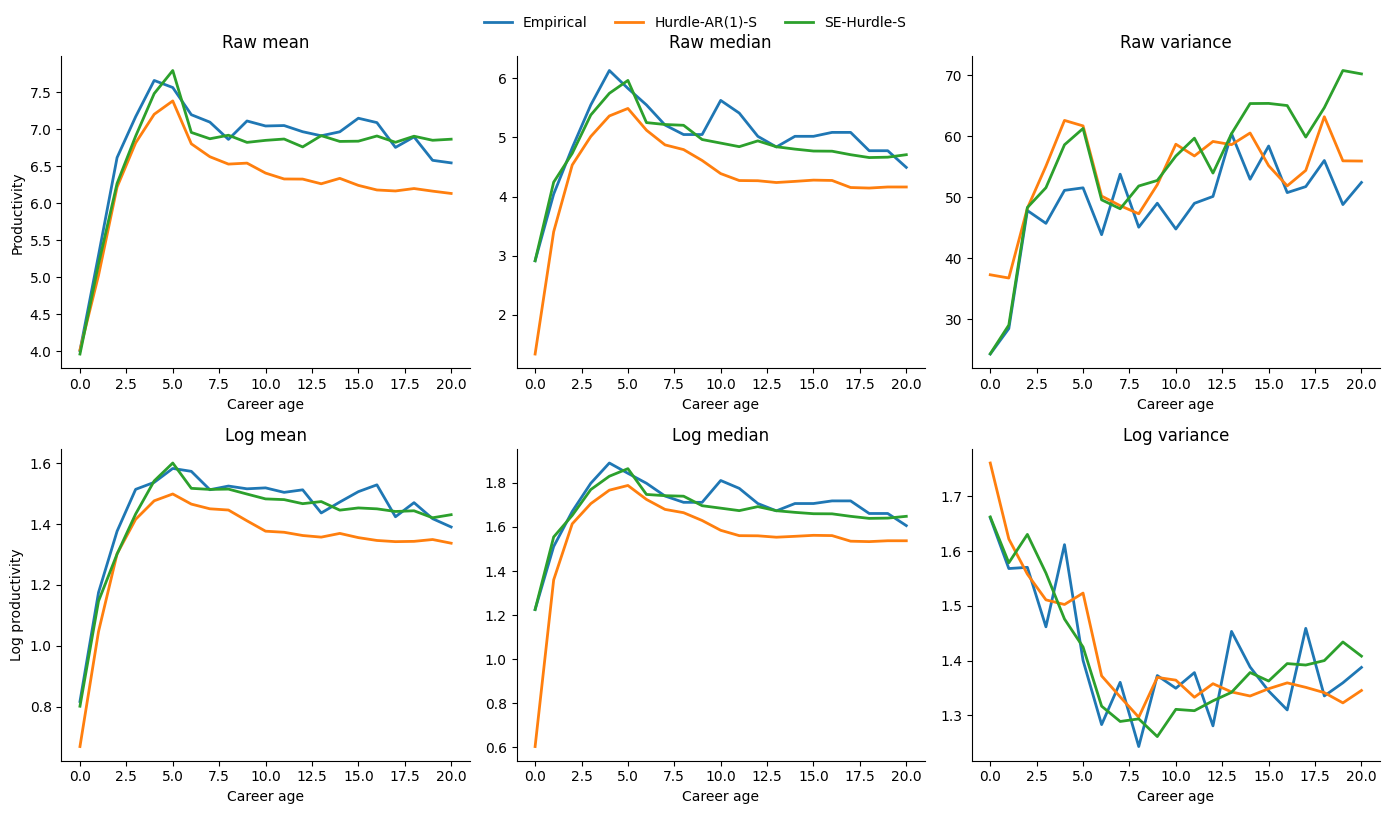

In [149]:
metrics = [
    ('mean', 'Raw mean'),
    ('median', 'Raw median'),
    ('variance', 'Raw variance'),
    ('log_mean', 'Log mean'),
    ('log_median', 'Log median'),
    ('log_variance', 'Log variance')]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (metric, title) in zip(axes.ravel(), metrics):
    for label, group in moment_stats.groupby('model', sort=False):
        ax.plot(group['year'], group[metric], linewidth=2, label=label)

    ax.set(title=title, xlabel='Career age')
    ax.spines[['top', 'right']].set_visible(False)

axes[0, 0].set_ylabel('Productivity')
axes[1, 0].set_ylabel('Log productivity')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'moment_trajectories.png', dpi=DPI, bbox_inches='tight')
plt.show()


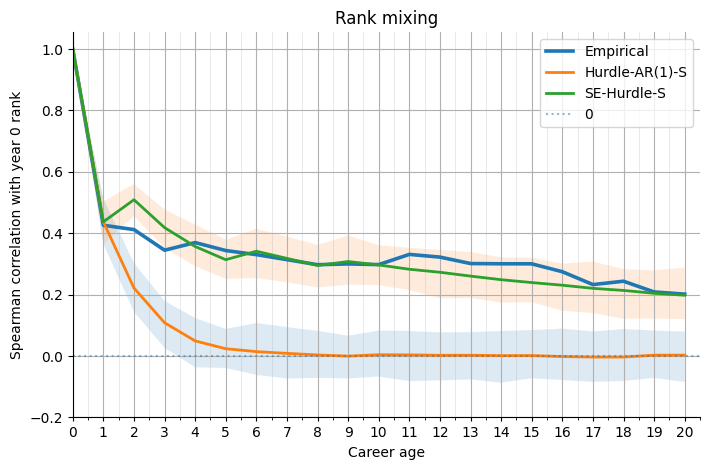

,model,terminal_persistence,persistence_rmse
0,Empirical,0.201571,0.000000
1,Hurdle-AR(1)-S,0.002951,0.267719
2,SE-Hurdle-S,0.197988,0.039111


In [150]:
def percentile_ranks(q):
    return np.column_stack([pd.Series(q[:, t]).rank(method='average', pct=True).to_numpy()for t in range(q.shape[1])])
def rank_curve(q):
    ranks = percentile_ranks(q)

    return np.array([stats.spearmanr(ranks[:, 0], ranks[:, t]).statistic for t in range(q.shape[1])])

def rank_replicates(simulator, seed):
    persistence = np.empty((N_RANK_REPS, Y + 1))

    for rep in range(N_RANK_REPS):
        simulated = simulator(N_EMP, seed + rep)
        persistence[rep] = rank_curve(simulated)

    return persistence

emp_persistence = rank_curve(Q_EMP)

hurdle_persistence = rank_replicates(
    lambda n, seed: simulate_hurdle_ar1(hurdle_model,n,seed),SEED + 1000)

self_persistence = rank_replicates(
    lambda n, seed: simulate_self_exciting(self_exciting_model,RHO_HAT,n,seed),SEED + 2000)

years = np.arange(Y + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(years,emp_persistence,linewidth=2.6,label='Empirical')

ax.plot(years,hurdle_persistence.mean(axis=0),linewidth=2,label=HURDLE_NAME)

ax.fill_between(years,np.quantile(hurdle_persistence, 0.025, axis=0),np.quantile(hurdle_persistence, 0.975, axis=0),alpha=0.15)

ax.plot(years,self_persistence.mean(axis=0),linewidth=2,label=MODEL_NAME)

ax.fill_between(years,np.quantile(self_persistence, 0.025, axis=0),np.quantile(self_persistence, 0.975, axis=0),alpha=0.15)

ax.set(title='Rank mixing',xlabel='Career age',ylabel='Spearman correlation with year 0 rank')

plt.axhline(0,xmax = 20, linestyle = 'dotted', alpha = 0.5, label = 0)

ax.set_ylim(bottom = -0.2)
ax.set_xlim(left = 0, right = 20)
ax.set_xticks(np.arange(0, 21, 1))
ax.set_xticks(np.arange(0, 21, 0.5), minor=True)

ax.grid(True, which="major", linewidth=0.8)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.5)
ax.tick_params(axis="x", which="major", length=3)


ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'rank_mixing.png',dpi=DPI,bbox_inches='tight')
plt.show()

rank_summary = pd.DataFrame({
    'model': ['Empirical',HURDLE_NAME,MODEL_NAME],
    'terminal_persistence': [emp_persistence[-1],hurdle_persistence[:, -1].mean(),self_persistence[:, -1].mean()],
    'persistence_rmse': [0.0,
        np.sqrt(np.mean((hurdle_persistence.mean(axis=0)- emp_persistence) ** 2)),
        np.sqrt(np.mean((self_persistence.mean(axis=0)- emp_persistence) ** 2))]
        })

rank_summary.to_csv(RESULT_DIR / 'rank_summary.csv',index=False)

rank_summary

In [151]:
print(hurdle_persistence.min())
print()
print(emp_persistence.min())
print()
print(self_persistence.min())

-0.14293458333016865

0.20157088641859774

0.10402410988486967


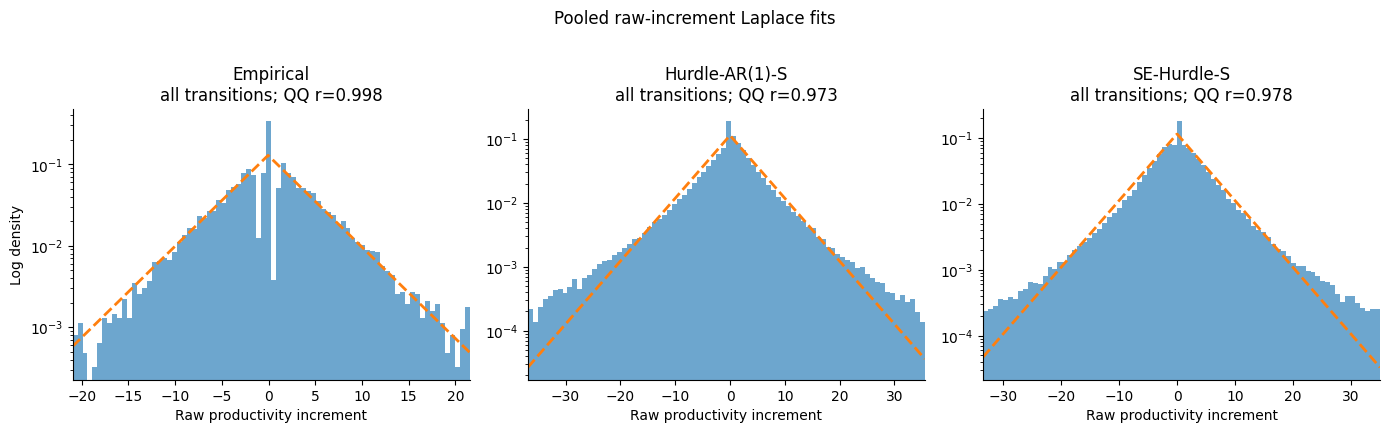

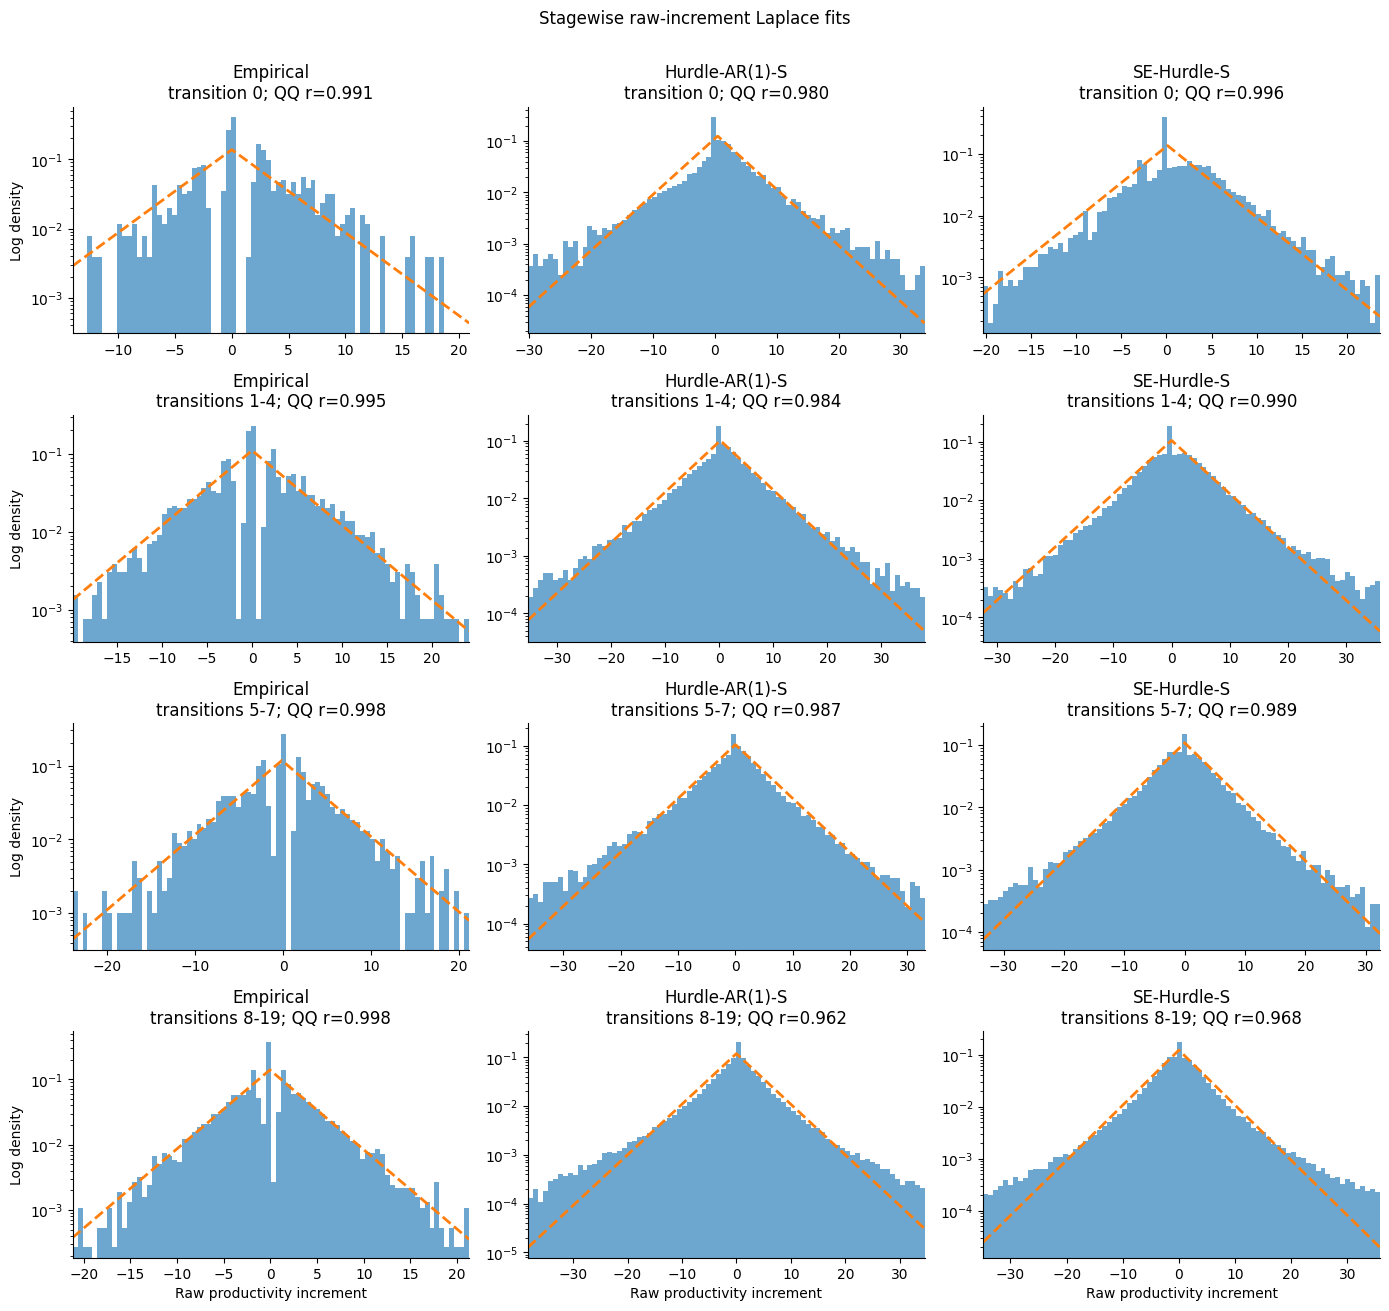

,model,stage,n,mu,scale,qq_r
0,Empirical,all transitions,11820,-0.056836,3.869668,0.998424
1,Hurdle-AR(1)-S,all transitions,200000,0.000000,4.416487,0.972632
2,SE-Hurdle-S,all transitions,200000,0.000000,4.289423,0.978156
3,Empirical,transition 0,591,0.000000,3.630528,0.991208
4,Hurdle-AR(1)-S,transition 0,10000,0.461006,3.988874,0.979573
5,SE-Hurdle-S,transition 0,10000,0.124880,3.700168,0.995771
6,Empirical,transitions 1-4,2364,0.000000,4.520534,0.994899
7,Hurdle-AR(1)-S,transitions 1-4,40000,0.179900,4.953036,0.984308
8,SE-Hurdle-S,transitions 1-4,40000,0.000000,4.773287,0.990001
9,Empirical,transitions 5-7,1773,-0.134692,4.261182,0.997725


In [152]:
INCREMENT_STAGES = {
    'transition 0': np.array([0]),
    'transitions 1-4': np.arange(1, 5),
    'transitions 5-7': np.arange(5, 8),
    'transitions 8-19': np.arange(8, Y)}

def laplace_fit(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    mu = np.median(values)
    scale = max(float(np.mean(np.abs(values - mu))), 1e-12)
    theoretical, observed = stats.probplot(values,dist=stats.laplace,sparams=(mu, scale),fit=False)
    qq_r = stats.pearsonr(theoretical, observed).statistic
    return mu, scale, qq_r, len(values)

def stage_increments(q, years=None):
    increments = np.diff(q, axis=1)
    if years is None:
        return increments.ravel()
    return increments[:, years].ravel()

def plot_laplace_hist(ax, values, model_label, subtitle, log_y=True):
    mu, scale, qq_r, n = laplace_fit(values)
    low, high = np.quantile(values, [0.002, 0.998])
    grid = np.linspace(low, high, 600)
    density = stats.laplace.pdf(grid, loc=mu, scale=scale)

    ax.hist(values,bins=80,density=True,alpha=0.65, range=(low, high))
    ax.plot(grid, density, linestyle='--', linewidth=2)
    ax.set_xlim(low, high)

    if log_y:
        ax.set_yscale('log')

    ax.set_title(f'{model_label}\n{subtitle}; QQ r={qq_r:.3f}')
    ax.spines[['top', 'right']].set_visible(False)

    return {'model': model_label,'stage': subtitle,'n': n,'mu': mu,'scale': scale,'qq_r': qq_r}

series = [('Empirical', Q_EMP),(HURDLE_NAME, Q_HURDLE),(MODEL_NAME, Q_SELF)]

laplace_rows = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (model_label, q) in zip(axes, series):
    laplace_rows.append(plot_laplace_hist(ax,stage_increments(q),model_label,'all transitions',log_y=True))
    ax.set_xlabel('Raw productivity increment')

axes[0].set_ylabel('Log density')
fig.suptitle('Pooled raw-increment Laplace fits', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'raw_increment_laplace_pooled.png',dpi=DPI,bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(4, 3, figsize=(14, 13))

for row, (stage_label, stage_years) in enumerate(INCREMENT_STAGES.items()):
    for col, (model_label, q) in enumerate(series):
        ax = axes[row, col]
        laplace_rows.append(plot_laplace_hist(ax,stage_increments(q, stage_years),model_label,stage_label,log_y=True))
        if col == 0:
            ax.set_ylabel('Log density')
        if row == 3:
            ax.set_xlabel('Raw productivity increment')

fig.suptitle('Stagewise raw-increment Laplace fits', y=1.005)
fig.tight_layout()
fig.savefig(FIG_DIR / 'raw_increment_laplace_stagewise.png',dpi=DPI,bbox_inches='tight')
plt.show()

laplace_summary = pd.DataFrame(laplace_rows)
laplace_summary.to_csv(RESULT_DIR / 'raw_increment_laplace.csv',index=False)
laplace_summary

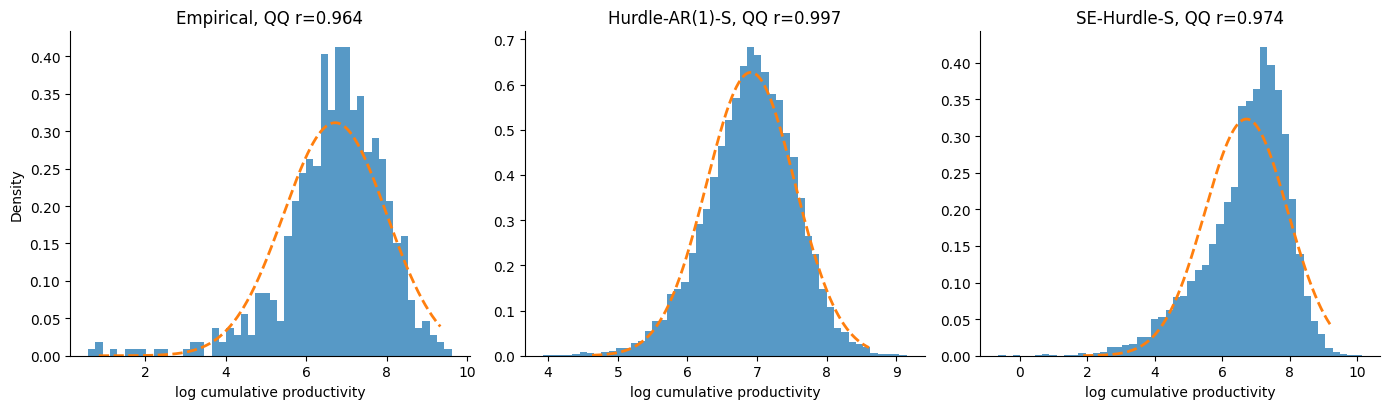

,model,n,log_mu,log_sigma,qq_r
0,Empirical,591,6.715421,1.281484,0.963785
1,Hurdle-AR(1)-S,10000,6.909168,0.636421,0.996851
2,SE-Hurdle-S,9997,6.719789,1.234030,0.973644


In [153]:
def cumulative_lognormal(q):
    cumulative = q.sum(axis=1)
    logged = np.log2(cumulative[cumulative > 0])
    mu = logged.mean()
    sigma = logged.std(ddof=0)
    theoretical, observed = stats.probplot(logged,dist='norm',sparams=(mu, sigma),fit=False)
    qq_r = stats.pearsonr(theoretical, observed).statistic
    return logged, mu, sigma, qq_r

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
lognormal_rows = []

for ax, (model_label, q) in zip(axes, series):
    logged, mu, sigma, qq_r = cumulative_lognormal(q)
    low, high = np.quantile(logged, [0.002, 0.998])
    grid = np.linspace(low, high, 500)

    ax.hist(logged, bins=50, density=True, alpha=0.75)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), linestyle='--', linewidth=2)
    ax.set(title=f'{model_label}, QQ r={qq_r:.3f}',xlabel=r'log cumulative productivity')
    ax.spines[['top', 'right']].set_visible(False)

    lognormal_rows.append({'model': model_label,'n': len(logged),'log_mu': mu, 'log_sigma': sigma,'qq_r': qq_r})

axes[0].set_ylabel('Density')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cumulative_lognormal.png', dpi=DPI, bbox_inches='tight')
plt.show()

lognormal_summary = pd.DataFrame(lognormal_rows)
lognormal_summary.to_csv(RESULT_DIR / 'cumulative_lognormal.csv', index=False)
lognormal_summary


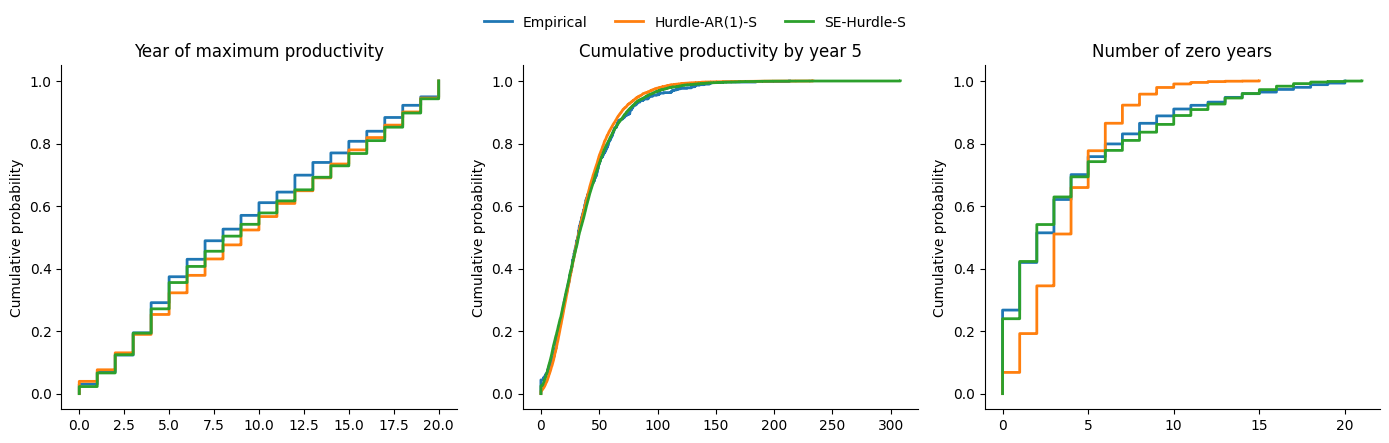

,diagnostic,model,ks_D,ks_p
0,Year of maximum productivity,Hurdle-AR(1)-S,0.058202,4.374035e-02
1,Year of maximum productivity,SE-Hurdle-S,0.047325,1.587633e-01
2,Cumulative productivity by year 5,Hurdle-AR(1)-S,0.038298,3.763065e-01
3,Cumulative productivity by year 5,SE-Hurdle-S,0.041549,2.821117e-01
4,Number of zero years,Hurdle-AR(1)-S,0.227428,7.777634e-26
5,Number of zero years,SE-Hurdle-S,0.028436,7.458204e-01


In [154]:
def ecdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    return values, np.arange(1, len(values) + 1) / len(values)

def ks_against_empirical(empirical, simulated):
    result = stats.ks_2samp(empirical, simulated)
    return result.statistic, result.pvalue

emp_year_max = np.argmax(Q_EMP, axis=1)
hurdle_year_max = np.argmax(Q_HURDLE, axis=1)
self_year_max = np.argmax(Q_SELF, axis=1)

emp_cum5 = Q_EMP[:, :6].sum(axis=1)
hurdle_cum5 = Q_HURDLE[:, :6].sum(axis=1)
self_cum5 = Q_SELF[:, :6].sum(axis=1)

emp_zero = (Q_EMP == 0).sum(axis=1)
hurdle_zero = (Q_HURDLE == 0).sum(axis=1)
self_zero = (Q_SELF == 0).sum(axis=1)

cdf_specs = [('Year of maximum productivity', emp_year_max, hurdle_year_max, self_year_max),
    ('Cumulative productivity by year 5', emp_cum5, hurdle_cum5, self_cum5),
    ('Number of zero years', emp_zero, hurdle_zero, self_zero)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
ks_rows = []

for ax, (title, empirical, hurdle, self_exciting) in zip(axes, cdf_specs):
    for label, values in [('Empirical', empirical),(HURDLE_NAME, hurdle),(MODEL_NAME, self_exciting)]:
        x, y = ecdf(values)
        ax.step(x, y, where='post', linewidth=2, label=label)

    for label, values in [(HURDLE_NAME, hurdle),(MODEL_NAME, self_exciting)]:
        d, p = ks_against_empirical(empirical, values)
        ks_rows.append({'diagnostic': title,'model': label,'ks_D': d,'ks_p': p})

    ax.set(title=title, ylabel='Cumulative probability')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'distributional_cdfs.png', dpi=DPI, bbox_inches='tight')
plt.show()

ks_summary = pd.DataFrame(ks_rows)
ks_summary.to_csv(RESULT_DIR / 'distributional_ks.csv', index=False)
ks_summary


In [155]:
summary = pd.DataFrame({
    'model': [HURDLE_NAME, MODEL_NAME],
    'rho': [np.nan, RHO_HAT],
    'memory_half_life': [np.nan, HALF_LIFE],
    'cv_nll': [HURDLE_CV_NLL, SELF_EXCITING_CV_NLL],
    'terminal_rank_persistence': [hurdle_persistence[:, -1].mean(), self_persistence[:, -1].mean()],
    'rank_persistence_rmse': [rank_summary.loc[rank_summary['model'].eq(HURDLE_NAME),'persistence_rmse'].iloc[0],rank_summary.loc[rank_summary['model'].eq(MODEL_NAME), 'persistence_rmse'].iloc[0]]})

summary.to_csv(RESULT_DIR / 'model_summary.csv', index=False)
summary

,model,rho,memory_half_life,cv_nll,terminal_rank_persistence,rank_persistence_rmse
0,Hurdle-AR(1)-S,NaN,NaN,1.352718,0.002951,0.267719
1,SE-Hurdle-S,0.6664,1.707826,1.082117,0.197988,0.039111


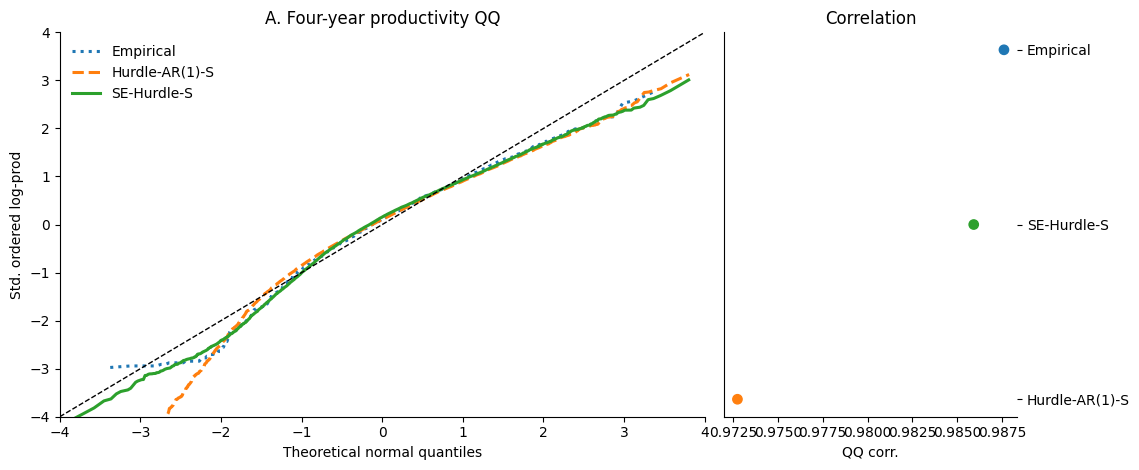

,model,window,n_positive,qq_r,log2_mean,log2_sd
0,Hurdle-AR(1)-S,Years 17-20,9830,0.972751,4.115424,1.396392
1,SE-Hurdle-S,Years 17-20,9620,0.985916,4.209917,1.483858
2,Empirical,Last four observed,1872,0.987600,4.123854,1.344266


In [156]:
def empirical_last_four():
    rolling = pd.read_csv(DATA/'df_rolling_pubs_cs.csv')

    person = "dblp"

    ordered = raw.copy()
    ordered["CareerAge"] = ordered["CareerAgeZero"].astype(int)
    ordered = ordered.sort_values([person, "CareerAge"])

    rolling4 = (ordered.groupby(person)["pubs_adj"].rolling(4, min_periods=4).sum().reset_index(level=0, drop=True))

    rolling = (ordered.assign(RollingPubs=rolling4).dropna(subset=["RollingPubs"]).groupby(person, as_index=False).agg(FourYearProd=("RollingPubs", "last"),TotalYears=("CareerAge", "max")))

    rolling = rolling.loc[rolling["TotalYears"].gt(4)& rolling["FourYearProd"].gt(0)].copy()

    return rolling["FourYearProd"].to_numpy(dtype=float)

def qq_details(productivity):
    productivity = np.asarray(productivity, dtype=float)
    productivity = productivity[np.isfinite(productivity) & (productivity > 0)]

    logged = np.log2(productivity)
    mu = logged.mean()
    sigma = logged.std(ddof=1)
    standardized = (logged - mu) / sigma

    (theoretical, ordered), (_, _, corr) = stats.probplot(standardized,dist="norm",fit=True,rvalue=True)

    return {"theoretical": theoretical,"ordered": ordered, "corr": float(corr),"n": len(logged), "log_mean": mu,"log_sd": sigma}

emp_last_four = empirical_last_four()
hurdle_last_four = Q_HURDLE[:, 17:21].sum(axis=1)
self_last_four = Q_SELF[:, 17:21].sum(axis=1)

qq_series = [("Empirical", emp_last_four, ":"),(HURDLE_NAME, hurdle_last_four, "--"),(MODEL_NAME, self_last_four, "-")]

fig, axes = plt.subplots(1,2,figsize=(11.5, 4.8),gridspec_kw={"width_ratios": [2.2, 1]})

rows = []
line_colors = {}

for label, values, linestyle in qq_series:
    details = qq_details(values)

    line, = axes[0].plot(details["theoretical"],details["ordered"],linewidth=2.2,linestyle=linestyle,label=label)

    line_colors[label] = line.get_color()

    rows.append({"model": label,
        "window": ("Last four observed" if label == "Empirical"else "Years 17-20"), "n_positive": details["n"], "qq_r": details["corr"], "log2_mean": details["log_mean"], "log2_sd": details["log_sd"]})

axes[0].plot([-4, 4],[-4, 4],linewidth=1,linestyle="--",color="black")

axes[0].set(xlim=(-4, 4), ylim=(-4, 4), xlabel="Theoretical normal quantiles",
    ylabel="Std. ordered log-prod",title="A. Four-year productivity QQ")

axes[0].legend(frameon=False)

qq_summary = (pd.DataFrame(rows).sort_values("qq_r").reset_index(drop=True))

y = np.arange(len(qq_summary))

axes[1].scatter(qq_summary["qq_r"],y,s=45,c=[line_colors[label]for label in qq_summary["model"]])

axes[1].set_yticks(y,qq_summary["model"])

axes[1].yaxis.tick_right()

axes[1].set(xlabel="QQ corr.",title="Correlation")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(FIG_DIR / "qq_last_four.png",dpi=DPI,bbox_inches="tight")
plt.show()

qq_summary.to_csv(RESULT_DIR / "qq_last_four.csv",index=False)

qq_summary


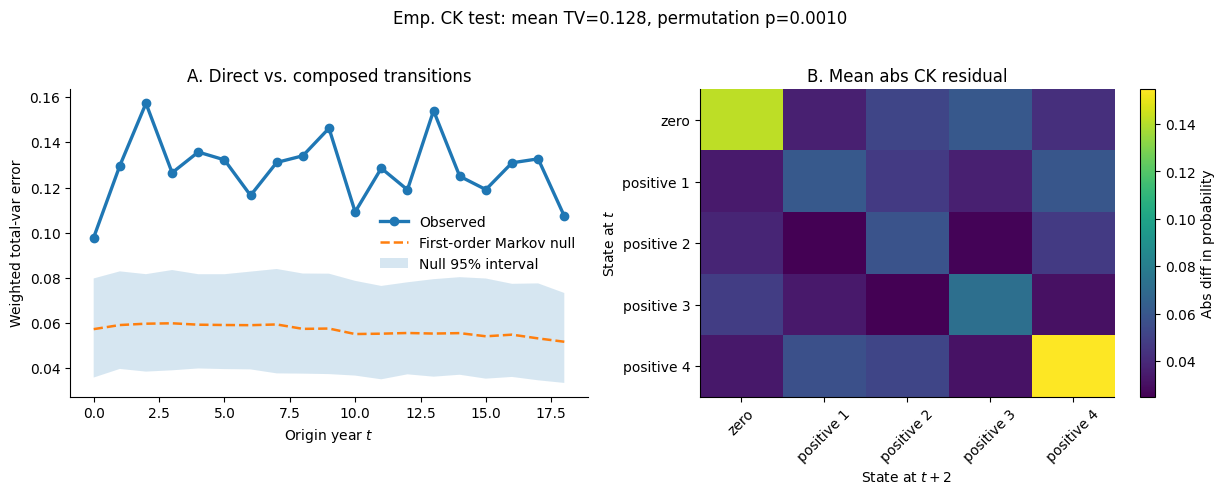

Observed mean CK error: 0.1280
Markov-null mean error: 0.0572
Permutation p-value: 0.000999
Conclusion: reject 1st-order CK 


,positive_bins,total_states,two_step_windows,observed_mean_weighted_tv,markov_null_mean_weighted_tv,markov_null_95_upper,permutation_p,reject_first_order_ck
0,4,5,19,0.128046,0.057221,0.061549,0.000999,True


In [157]:
N_CK_POSITIVE_BINS = 4
N_CK_PERM = 1000

def productivity_states(q, n_positive_bins=N_CK_POSITIVE_BINS):
    positive = np.log1p(q[q > 0])
    edges = np.unique(np.quantile(positive, np.linspace(0, 1, n_positive_bins + 1)))

    states = np.zeros_like(q, dtype=int)
    mask = q > 0
    states[mask] = (1+ np.digitize(np.log1p(q[mask]),edges[1:-1],right=True))

    labels = ['zero'] + [f'positive {j}' for j in range(1, len(edges))]

    return states, edges, labels

def transition_matrix(origin, destination, n_states):
    counts = np.zeros((n_states, n_states), dtype=float)
    np.add.at(counts, (origin, destination), 1)

    totals = counts.sum(axis=1, keepdims=True)

    probabilities = np.divide(counts,totals,out=np.zeros_like(counts),where=totals > 0)

    return probabilities, counts

def ck_error(direct, composed, origin_counts):
    row_tv = 0.5 * np.abs(direct - composed).sum(axis=1)
    weights = origin_counts / origin_counts.sum()

    return float(np.sum(weights * row_tv))

ck_states, ck_edges, ck_labels = productivity_states(Q_EMP)
n_ck_states = len(ck_labels)

ck_windows = []
ck_rows = []
ck_residual_rows = []

for t in range(Y - 1):
    z0 = ck_states[:, t]
    z1 = ck_states[:, t + 1]
    z2 = ck_states[:, t + 2]

    p01, c01 = transition_matrix(z0, z1, n_ck_states)
    p12, c12 = transition_matrix(z1, z2, n_ck_states)
    p02, c02 = transition_matrix(z0, z2, n_ck_states)

    composed = p01 @ p12
    origin_counts = c02.sum(axis=1)
    error = ck_error(p02, composed, origin_counts)

    ck_windows.append({'year': t,'z0': z0,'z1': z1,'z2': z2,'composed': composed,'origin_counts': origin_counts})

    ck_rows.append({'year': t,'target_year': t + 2,'weighted_tv': error,'max_abs_residual': np.abs(p02 - composed).max()})

    for origin in range(n_ck_states):
        for destination in range(n_ck_states):
            ck_residual_rows.append({
                'year': t,
                'origin_state': ck_labels[origin],
                'destination_state': ck_labels[destination],
                'direct_probability': p02[origin, destination],
                'composed_probability': composed[origin, destination],
                'residual': (p02[origin, destination] - composed[origin, destination])})

ck_year = pd.DataFrame(ck_rows)
ck_residual = pd.DataFrame(ck_residual_rows)

ck_observed = ck_year['weighted_tv'].mean()

rng = np.random.default_rng(SEED + 5000)
ck_perm_year = np.empty((N_CK_PERM, Y - 1))

for b in range(N_CK_PERM):
    for j, window in enumerate(ck_windows):
        z2_perm = window['z2'].copy()
        for middle_state in range(n_ck_states):
            idx = np.flatnonzero(window['z1'] == middle_state)

            if len(idx) > 1:
                z2_perm[idx] = rng.permutation(z2_perm[idx])

        p02_perm, _ = transition_matrix(window['z0'],z2_perm,n_ck_states)

        ck_perm_year[b, j] = ck_error(p02_perm,window['composed'],window['origin_counts'])

ck_perm_global = ck_perm_year.mean(axis=1)

ck_p = (1 + np.sum(ck_perm_global >= ck_observed)) / (N_CK_PERM + 1)

ck_year['null_median'] = np.median(ck_perm_year,axis=0)

ck_year['null_low'] = np.quantile(ck_perm_year,0.025,axis=0)

ck_year['null_high'] = np.quantile(ck_perm_year,0.975,axis=0)

ck_summary = pd.DataFrame([{
    'positive_bins': N_CK_POSITIVE_BINS,
    'total_states': n_ck_states,
    'two_step_windows': Y - 1,
    'observed_mean_weighted_tv': ck_observed,
    'markov_null_mean_weighted_tv': ck_perm_global.mean(),
    'markov_null_95_upper': np.quantile(ck_perm_global,0.95),
    'permutation_p': ck_p,
    'reject_first_order_ck': ck_p < 0.05
}])

mean_abs_residual = (ck_residual.assign(abs_residual=lambda d: d['residual'].abs()).groupby(['origin_state','destination_state'])['abs_residual'].mean().unstack().reindex(index=ck_labels,columns=ck_labels))

fig, axes = plt.subplots(1,2,figsize=(12.5, 4.8))

axes[0].plot(ck_year['year'],ck_year['weighted_tv'],marker='o',linewidth=2.4,label='Observed')

axes[0].plot(ck_year['year'],ck_year['null_median'],linestyle='--',linewidth=1.8,label='First-order Markov null')

axes[0].fill_between(ck_year['year'],ck_year['null_low'],ck_year['null_high'],alpha=0.18,label='Null 95% interval')

axes[0].set(xlabel=r'Origin year $t$',ylabel='Weighted total-var error',title='A. Direct vs. composed transitions')

axes[0].legend(frameon=False)

image = axes[1].imshow(
    mean_abs_residual.to_numpy(),
    aspect='auto')

axes[1].set(
    xticks=np.arange(n_ck_states),
    yticks=np.arange(n_ck_states),
    xticklabels=ck_labels,
    yticklabels=ck_labels,
    xlabel=r'State at $t+2$',
    ylabel=r'State at $t$',
    title='B. Mean abs CK residual')

axes[1].tick_params(axis='x',rotation=45)

fig.colorbar(image,ax=axes[1],label='Abs diff in probability')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emp. CK test: 'f'mean TV={ck_observed:.3f}, 'f'permutation p={ck_p:.4f}',y=1.02)

fig.tight_layout()

fig.savefig(FIG_DIR / 'chapman_kolmogorov_test.png',dpi=DPI,bbox_inches='tight')

plt.show()

print(
    f'Observed mean CK error: {ck_observed:.4f}\n'
    f'Markov-null mean error: '
    f'{ck_perm_global.mean():.4f}\n'
    f'Permutation p-value: {ck_p:.4g}\n'
    f'Conclusion: '
    f'{"reject 1st-order CK "
       if ck_p < 0.05
       else "don't reject 1st-order CK"}')

ck_summary

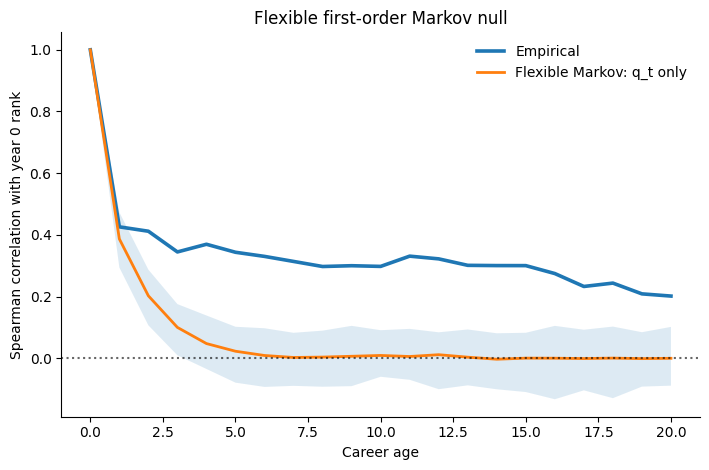

Empirical terminal persistence: 0.202
Flexible-Markov terminal persistence: -0.000 [-0.089, 0.102]


,model,terminal_rank_persistence,terminal_ci_low,terminal_ci_high,rank_curve_rmse
0,Empirical,0.201571,NaN,NaN,0.00000
1,Flexible Markov: q_t only,-0.000177,-0.088886,0.101611,0.26859


In [158]:
MARKOV_K = 75
MARKOV_REPS = 100

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def markov_rank_curve(q):
    ranks = np.column_stack([pd.Series(q[:, t]).rank(method="average",pct=True).to_numpy() for t in range(q.shape[1])])

    return np.array([stats.spearmanr(ranks[:, 0],ranks[:, t]).statistic for t in range(q.shape[1])])


def fit_markov_knn(q, k=MARKOV_K):
    kernels = {}

    for t in range(q.shape[1] - 1):
        current_log_q = np.log(q[:, t] + EPS)
        current_active = q[:, t] > 0

        for state in [0, 1]:
            idx = np.flatnonzero(current_active == state)

            next_q = q[idx, t + 1]

            if state == 0:

                kernels[(t, state)] = {"next_q": next_q, "tree": None}
                continue

            x = current_log_q[idx]
            center = float(np.median(x))
            scale = float(np.std(x))

            if not np.isfinite(scale) or scale <= 0:
                scale = 1.0

            x_scaled = ((x - center) / scale)[:, None]

            kernels[(t, state)] = {
                "next_q": next_q,
                "tree": cKDTree(x_scaled),
                "center": center,
                "scale": scale,
                "k": min(k, len(idx))}

    return kernels


def simulate_markov_knn(empirical_q,kernels,n_sim,seed):
    rng = np.random.default_rng(seed)

    simulated = np.zeros((n_sim, empirical_q.shape[1]),dtype=float)

    simulated[:, 0] = rng.choice(empirical_q[:, 0],size=n_sim,replace=True)
    
    for t in range(empirical_q.shape[1] - 1):
        current_q = simulated[:, t]
        current_active = current_q > 0

        for state in [0, 1]:
            rows = np.flatnonzero(current_active == state)

            if len(rows) == 0:
                continue

            kernel = kernels[(t, state)]

            if state == 0:
                simulated[rows, t + 1] = rng.choice(kernel["next_q"],size=len(rows),replace=True)
                continue

            x = ((np.log(current_q[rows] + EPS) - kernel["center"])/ kernel["scale"])[:, None]

            _, neighbors = kernel["tree"].query(x,k=kernel["k"],workers=1)

            if neighbors.ndim == 1:
                neighbors = neighbors[:, None]

            choice = rng.integers(0,neighbors.shape[1],size=len(rows))

            selected = neighbors[np.arange(len(rows)),choice]

            simulated[rows, t + 1] = (kernel["next_q"][selected])

    return simulated


markov_kernels = fit_markov_knn(Q_EMP)

emp_markov_rank = markov_rank_curve(Q_EMP)

markov_rank_draws = np.empty((MARKOV_REPS, Y + 1))

for rep in range(MARKOV_REPS):
    q_markov = simulate_markov_knn(Q_EMP,markov_kernels,N_EMP, SEED + 3000 + rep)

    markov_rank_draws[rep] = ( markov_rank_curve(q_markov))

markov_rank_mean = ( markov_rank_draws.mean(axis=0))

markov_rank_low = np.quantile(markov_rank_draws,0.001,axis=0)

markov_rank_high = np.quantile(markov_rank_draws,0.999,axis=0)

markov_summary = pd.DataFrame({
    "model": ["Empirical","Flexible Markov: q_t only"],
    "terminal_rank_persistence": [emp_markov_rank[-1],markov_rank_mean[-1]],
    "terminal_ci_low": [np.nan,markov_rank_low[-1]],
    "terminal_ci_high": [np.nan,markov_rank_high[-1]],
    "rank_curve_rmse": [0.0,np.sqrt(np.mean((markov_rank_mean - emp_markov_rank) ** 2))]
        })

years = np.arange(Y + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.plot(years,emp_markov_rank,linewidth=2.6,label="Empirical")

ax.plot(years, markov_rank_mean,linewidth=2,label="Flexible Markov: q_t only")

ax.fill_between(years,markov_rank_low,markov_rank_high,alpha=0.15)

ax.set(title="Flexible first-order Markov null",xlabel="Career age",ylabel="Spearman correlation with year 0 rank")

ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
ax.axhline(0, linestyle = 'dotted', color = 'black', alpha = 0.6)
fig.tight_layout()

fig.savefig(FIG_DIR / "knn_markov_rank_mixing.png",dpi=DPI,bbox_inches="tight")

plt.show()

markov_summary.to_csv(RESULT_DIR / "knn_markov_rank_summary.csv",index=False)

print("Empirical terminal persistence: "f"{emp_markov_rank[-1]:.3f}")

print("Flexible-Markov terminal persistence: "
    f"{markov_rank_mean[-1]:.3f} "
    f"[{markov_rank_low[-1]:.3f}, "
    f"{markov_rank_high[-1]:.3f}]")

markov_summary



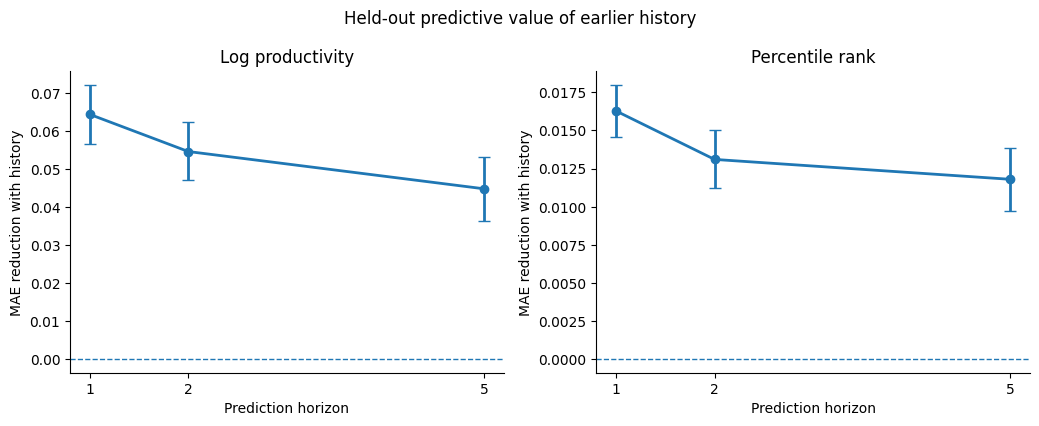

All history-gain confidence intervals exclude zero: True


,target,horizon,n,mae_base,mae_history,mae_gain,gain_ci_low,gain_ci_high,rho_base,rho_history,ci_excludes_zero
0,Log productivity,1,11820,0.741760,0.677443,0.064317,0.056530,0.072031,0.625946,0.689395,True
1,Log productivity,2,11229,0.751691,0.697143,0.054548,0.046945,0.062252,0.602591,0.658256,True
2,Log productivity,5,9456,0.796630,0.751876,0.044754,0.036205,0.053226,0.508860,0.568464,True
3,Percentile rank,1,11820,0.183085,0.166804,0.016281,0.014547,0.017983,0.623620,0.688862,True
4,Percentile rank,2,11229,0.187293,0.174193,0.013101,0.011213,0.015010,0.600903,0.656983,True
5,Percentile rank,5,9456,0.205844,0.194048,0.011796,0.009684,0.013856,0.504164,0.564450,True


In [159]:
PREDICTION_HORIZONS = [1, 2, 5]
PREDICTION_BOOTSTRAPS = N_BOOT

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def history_run_lengths(active):
    active = np.asarray(active, dtype=bool)

    active_run = np.zeros(active.size,dtype=int)

    zero_run = np.zeros(active.size,dtype=int)

    a = 0
    z = 0

    for t, value in enumerate(active):
        a = a + 1 if value else 0
        z = z + 1 if not value else 0

        active_run[t] = a
        zero_run[t] = z

    return active_run, zero_run


def build_history_prediction_data(q, ids):
    pieces = []

    for scholar_id, trajectory in zip(ids, q):
        trajectory = np.asarray(trajectory,dtype=float)

        logged = np.log(trajectory + EPS)

        active = trajectory > 0

        active_run, zero_run = (history_run_lengths(active))

        scholar = pd.DataFrame({
            "scholar_id": scholar_id,
            "year": np.arange(trajectory.size),
            "q": trajectory,"z": logged,
            "active": active.astype(int),
            "dz1": np.r_[np.nan,np.diff(logged)],
            "slope3": np.r_[np.nan,np.nan,(logged[2:] - logged[:-2]) / 2],
            "sd3": (pd.Series(logged).rolling(3,min_periods=2).std(ddof=0).to_numpy()),
            "log_cum_q": np.log1p(np.cumsum(trajectory)),
            "drawdown": (np.log1p(np.maximum.accumulate(trajectory))- np.log1p(trajectory)),
            "active_run": active_run,
            "zero_run": zero_run})

        pieces.append(scholar)

    data = pd.concat(pieces,ignore_index=True)

    data["rank_pct"] = (data.groupby("year")["q"].rank(method="average",pct=True))

    grouped = data.groupby("scholar_id",sort=False)

    for horizon in PREDICTION_HORIZONS:
        data[f"z_f{horizon}"] = (grouped["z"].shift(-horizon))

        data[f"rank_f{horizon}"] = (grouped["rank_pct"].shift(-horizon))

    return data


BASE_PREDICTORS = ["year","z","active"]

HISTORY_PREDICTORS = (BASE_PREDICTORS + [
        "dz1",
        "slope3",
        "sd3",
        "log_cum_q",
        "drawdown",
        "active_run",
        "zero_run"])


def history_prediction_model():
    return make_pipeline(SimpleImputer(strategy="median"),HistGradientBoostingRegressor(learning_rate=0.05,max_depth=3,max_iter=300,l2_regularization=1.0,random_state=SEED))


def clustered_mae_gain_ci(y,pred_base,pred_history,groups,n_boot=PREDICTION_BOOTSTRAPS,seed=SEED):
    rng = np.random.default_rng(seed)

    unique_groups = pd.unique(groups)

    indices = {group: np.flatnonzero(groups == group) for group in unique_groups}

    observed_gain = (np.mean(np.abs(y - pred_base))- np.mean(np.abs(y - pred_history)))

    draws = np.empty(n_boot)

    for b in range(n_boot):
        sampled_groups = rng.choice(unique_groups,size=len(unique_groups),replace=True)

        sampled_indices = np.concatenate([indices[group]for group in sampled_groups])

        draws[b] = (np.mean(np.abs(y[sampled_indices] - pred_base[sampled_indices]))- np.mean(np.abs(y[sampled_indices]- pred_history[sampled_indices])))

    return (observed_gain,np.quantile(draws,[0.025, 0.975]))


def compare_history_prediction(data,target,target_type,horizon):
    columns = list(dict.fromkeys(BASE_PREDICTORS + HISTORY_PREDICTORS + [target,"scholar_id"]))

    use = (data[columns].dropna(subset=[target]).copy())

    y = use[target].to_numpy()
    groups = (use["scholar_id"].to_numpy())

    cv = GroupKFold(n_splits=N_SPLITS)

    pred_base = cross_val_predict(history_prediction_model(),use[BASE_PREDICTORS],y,groups=groups,cv=cv,n_jobs=1)

    pred_history = cross_val_predict(history_prediction_model(),use[HISTORY_PREDICTORS],y,groups=groups,cv=cv,n_jobs=1)

    gain, interval = (clustered_mae_gain_ci(y, pred_base,pred_history,groups,seed=SEED + horizon))

    return {
        "target": target_type,
        "horizon": horizon,
        "n": len(use),
        "mae_base": np.mean(np.abs(y - pred_base)),
        "mae_history": np.mean(np.abs(y - pred_history)),
        "mae_gain": gain,
        "gain_ci_low": interval[0],
        "gain_ci_high": interval[1],
        "rho_base": stats.spearmanr(y,pred_base).statistic,
        "rho_history": stats.spearmanr(y,pred_history).statistic}


history_prediction_data = (build_history_prediction_data(Q_EMP,EMP_IDS))

prediction_rows = []

for target_type, prefix in [("Log productivity", "z"),("Percentile rank", "rank")]:
    for horizon in PREDICTION_HORIZONS:
        prediction_rows.append(compare_history_prediction(history_prediction_data,f"{prefix}_f{horizon}",target_type,horizon))

history_prediction_results = (pd.DataFrame(prediction_rows))

history_prediction_results[ "ci_excludes_zero"] = (history_prediction_results[ "gain_ci_low" ] > 0)

history_prediction_results.to_csv(RESULT_DIR / "history_predictive_gain.csv",index=False)


fig, axes = plt.subplots(1,2,figsize=(10.5, 4.3))

for ax, target_type in zip(axes,[ "Log productivity", "Percentile rank"]):
    subset = (history_prediction_results[history_prediction_results["target"].eq(target_type)].sort_values("horizon"))

    yerr = np.vstack([subset["mae_gain"]- subset["gain_ci_low"],subset["gain_ci_high"] - subset["mae_gain"]])

    ax.errorbar(subset["horizon"],subset["mae_gain"],yerr=yerr, marker="o",linewidth=2,capsize=4)

    ax.axhline(0,linewidth=1,linestyle="--")

    ax.set(title=target_type,xlabel="Prediction horizon",ylabel=("MAE reduction with history"),xticks=PREDICTION_HORIZONS)

    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Held-out predictive value of earlier history")

fig.tight_layout()

fig.savefig(FIG_DIR/ "history_predictive_gain.png",dpi=DPI,bbox_inches="tight")

plt.show()

print( "All history-gain confidence intervals ""exclude zero:",history_prediction_results[ "ci_excludes_zero"].all())

history_prediction_results



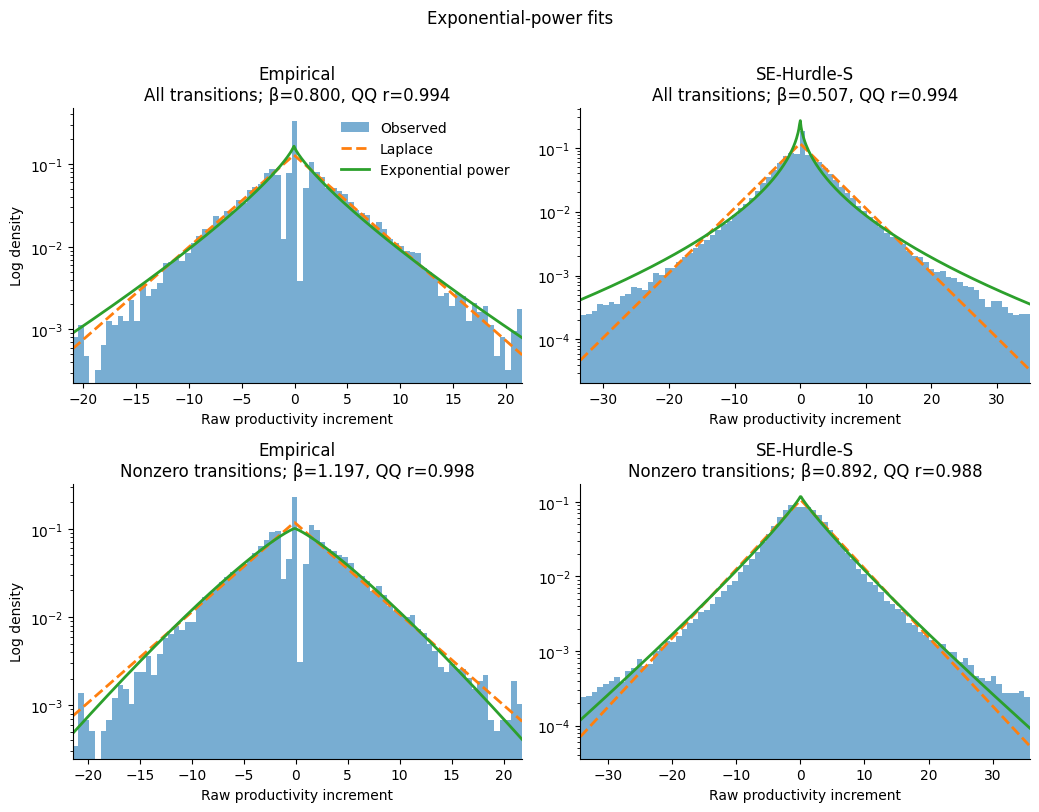

,model,sample,n,ad_n,beta,loc,scale,qq_r_ep,qq_r_laplace,delta_aic_ep_minus_laplace,delta_bic_ep_minus_laplace,lr_stat,lr_p,ad_stat,ad_p
0,Empirical,All transitions,11820,3000,0.799539,-6.007497e-02,2.646710,0.994120,0.998398,-89.904788,-82.527240,91.904788,9.094870e-22,12.364642,0.005
1,SE-Hurdle-S,All transitions,200000,3000,0.506532,-3.169268e-16,0.795686,0.993690,0.978231,-15022.946122,-15012.740049,15024.946122,0.000000e+00,5.219609,0.005
2,Empirical,Nonzero transitions,10829,3000,1.197478,-1.020788e-01,5.262289,0.998239,0.997472,-78.534659,-71.244676,80.534659,2.856505e-19,5.935611,0.005
3,SE-Hurdle-S,Nonzero transitions,182326,3000,0.892380,3.981924e-02,3.934604,0.987781,0.982143,-962.075240,-951.961688,964.075240,1.156530e-211,1.815628,0.015


In [161]:
def exponential_power_fit(values, rng):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    beta, loc, scale = stats.gennorm.fit(values)
    lap_loc, lap_scale = stats.laplace.fit(values)

    ll_ep = stats.gennorm.logpdf(values, beta, loc=loc, scale=scale).sum()
    ll_lap = stats.laplace.logpdf(values, loc=lap_loc, scale=lap_scale).sum()

    p = (np.arange(len(values)) + 0.5) / len(values)
    observed = np.sort(values)
    ep_q = stats.gennorm.ppf(p, beta, loc=loc, scale=scale)
    lap_q = stats.laplace.ppf(p, loc=lap_loc, scale=lap_scale)

    gof_values = rng.choice(values, size=min(3000, len(values)), replace=False)
    gof = stats.goodness_of_fit(stats.gennorm,gof_values,statistic='ad',n_mc_samples=199,random_state=rng)

    lr = max(0, 2 * (ll_ep - ll_lap))

    return {
        'n': len(values),'ad_n': len(gof_values),
        'beta': beta,'loc': loc,'scale': scale,
        'lap_loc': lap_loc,'lap_scale': lap_scale,
        'qq_r_ep': stats.pearsonr(ep_q, observed).statistic,'qq_r_laplace': stats.pearsonr(lap_q, observed).statistic,
        'delta_aic_ep_minus_laplace': (6 - 2 * ll_ep) - (4 - 2 * ll_lap),
        'delta_bic_ep_minus_laplace': (3 * np.log(len(values)) - 2 * ll_ep- (2 * np.log(len(values)) - 2 * ll_lap)),
        'lr_stat': lr,'lr_p': stats.chi2.sf(lr, 1),
        'ad_stat': gof.statistic,
        'ad_p': gof.pvalue}

ep_series = [('Empirical', Q_EMP),(MODEL_NAME, Q_SELF)]

ep_samples = [('All transitions', False),('Nonzero transitions', True)]

ep_rng = np.random.default_rng(SEED + 7000)
ep_rows = []

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8))

for row, (sample_label, nonzero) in enumerate(ep_samples):
    for col, (model_label, q) in enumerate(ep_series):
        ax = axes[row, col]
        values = np.diff(q, axis=1).ravel()
        values = values[np.isfinite(values)]

        if nonzero:
            values = values[values != 0]

        fit = exponential_power_fit(values, ep_rng)
        low, high = np.quantile(values, [0.002, 0.998])
        grid = np.linspace(low, high, 600)

        ax.hist(values,bins=80,density=True,alpha=0.6,range=(low, high),label='Observed')

        ax.plot(grid,stats.laplace.pdf(grid,fit['lap_loc'],fit['lap_scale']),linestyle='--',linewidth=2,label='Laplace')

        ax.plot(grid,stats.gennorm.pdf(grid,fit['beta'],fit['loc'],fit['scale']),linewidth=2,label='Exponential power')

        ax.set_yscale('log')
        ax.set_xlim(low, high)
        ax.set(title=(f'{model_label}\n'f'{sample_label}; β={fit["beta"]:.3f}, 'f'QQ r={fit["qq_r_ep"]:.3f}'),xlabel='Raw productivity increment')

        ax.spines[['top', 'right']].set_visible(False)

        ep_rows.append({'model': model_label,'sample': sample_label,**{key: value for key, value in fit.items() if key not in ['lap_loc', 'lap_scale']}})

axes[0, 0].set_ylabel('Log density')
axes[1, 0].set_ylabel('Log density')
axes[0, 0].legend(frameon=False)

fig.suptitle('Exponential-power fits',y=1.01)

fig.tight_layout()

fig.savefig(FIG_DIR / 'raw_increment_exponential_power.png',dpi=DPI,bbox_inches='tight')

plt.show()

exp_power_summary = pd.DataFrame(ep_rows)

exp_power_summary.to_csv( RESULT_DIR / 'raw_increment_exponential_power.csv',index=False)

exp_power_summary

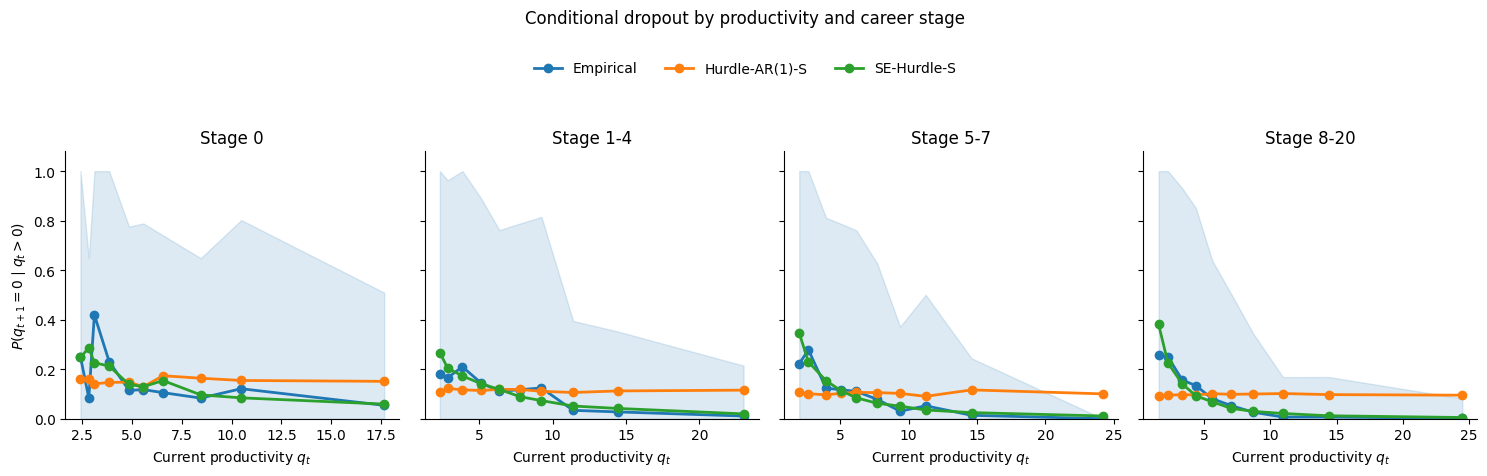

,q_bin,dropout_probability,n,q_mean,se,low,high,model,stage
0,0,0.250000,44,2.430021,0.498578,0.0,1.000000,Empirical,0
1,1,0.083333,36,2.848328,0.288341,0.0,0.648481,Empirical,0
2,2,0.419355,31,3.128785,0.643181,0.0,1.000000,Empirical,0
3,3,0.230769,39,3.868114,0.478961,0.0,1.000000,Empirical,0
4,4,0.114286,35,4.863212,0.337509,0.0,0.775804,Empirical,0
...,...,...,...,...,...,...,...,...,...
115,5,0.041900,10883,7.034201,0.204695,0.0,0.443102,SE-Hurdle-S,8-20
116,6,0.029703,9696,8.707306,0.172345,0.0,0.367500,SE-Hurdle-S,8-20
117,7,0.021128,8567,10.940980,0.145353,0.0,0.306020,SE-Hurdle-S,8-20
118,8,0.011911,8899,14.385268,0.109140,0.0,0.225825,SE-Hurdle-S,8-20


In [163]:
def conditional_dropout_rows(q, model_label):
    rows = []

    for t in range(Y):
        current = q[:, t]
        active = current > 0

        rows.append(pd.DataFrame({ 'model': model_label,'stage': transition_stage(t),'q_prev': current[active],'dropout': (q[active, t + 1] == 0).astype(int)}))

    return pd.concat(rows, ignore_index=True)

dropout_data = pd.concat([conditional_dropout_rows(Q_EMP, 'Empirical'),conditional_dropout_rows(Q_HURDLE, HURDLE_NAME),conditional_dropout_rows(Q_SELF, MODEL_NAME)],
    ignore_index=True)

dropout_rows = []

for stage in STAGE_ORDER:
    empirical = dropout_data[dropout_data['model'].eq('Empirical') & dropout_data['stage'].eq(stage)]

    edges = np.unique(np.quantile(np.log1p(empirical['q_prev']),np.linspace(0, 1, 11)))

    centers = (empirical.assign(q_bin=np.digitize(np.log1p(empirical['q_prev']),edges[1:-1],right=True)).groupby('q_bin')['q_prev'].mean())

    for model_label in ['Empirical', HURDLE_NAME, MODEL_NAME]:
        d = dropout_data[dropout_data['model'].eq(model_label) & dropout_data['stage'].eq(stage)].copy()

        d['q_bin'] = np.digitize(np.log1p(d['q_prev']),edges[1:-1],right=True)

        fitted = (d.groupby('q_bin').agg(dropout_probability=('dropout', 'mean'),n=('dropout', 'size')).reset_index())

        fitted['q_mean'] = fitted['q_bin'].map(centers)

        fitted['se'] = np.sqrt(fitted['dropout_probability'] * (1 - fitted['dropout_probability'] / fitted['n']))

        fitted['low'] = (fitted['dropout_probability']- 1.96 * fitted['se']).clip(0, 1)

        fitted['high'] = (fitted['dropout_probability']+ 1.96 * fitted['se']).clip(0, 1)

        fitted['model'] = model_label
        fitted['stage'] = stage
        dropout_rows.append(fitted)

conditional_dropout = pd.concat(dropout_rows,ignore_index=True)

fig, axes = plt.subplots(1,4,figsize=(15, 4),sharey=True)

for ax, stage in zip(axes, STAGE_ORDER):
    stage_data = conditional_dropout[
        conditional_dropout['stage'].eq(stage)]

    for model_label in ['Empirical', HURDLE_NAME, MODEL_NAME]:
        d = stage_data[stage_data['model'].eq(model_label)]

        line, = ax.plot(d['q_mean'],d['dropout_probability'],marker='o',linewidth=2,label=model_label)

        if model_label == 'Empirical':
            ax.fill_between(d['q_mean'],d['low'],d['high'],alpha=0.15,color=line.get_color())

    #ax.set_xscale('log')
    ax.set(title=f'Stage {stage}',xlabel=r'Current productivity $q_t$',ylim=(0,conditional_dropout['high'].max() * 1.08))

    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel(r'$P(q_{t+1}=0\mid q_t>0)$')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5, 1.08),ncol=3,frameon=False)

fig.suptitle('Conditional dropout by productivity and career stage',y=1.18)

fig.tight_layout()

fig.savefig(FIG_DIR / 'conditional_dropout.png',dpi=DPI,bbox_inches='tight')

plt.show()

conditional_dropout.to_csv( RESULT_DIR / 'conditional_dropout.csv',index=False)

conditional_dropout

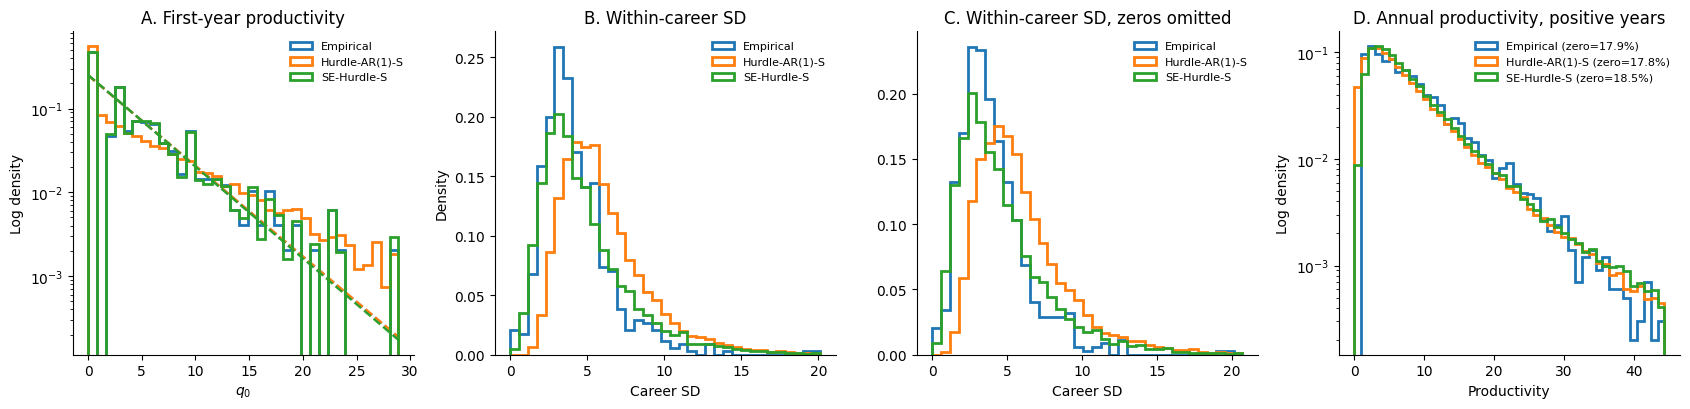

,model,q0_exponential_scale,q0_zero_fraction,career_sd_mean,career_sd_median,career_sd_ks_D,career_sd_ks_p,positive_career_sd_mean,positive_career_sd_median,positive_career_sd_ks_D,positive_career_sd_ks_p,annual_zero_fraction,annual_positive_ks_D,annual_positive_ks_p
0,Empirical,4.011242,0.385787,4.290433,3.808595,0.000000,1.000000e+00,4.079631,3.598374,0.000000,1.000000e+00,0.179357,0.000000,1.000000e+00
1,Hurdle-AR(1)-S,4.019222,0.384100,6.198790,5.496159,0.319579,3.954145e-51,6.083836,5.326553,0.310366,6.975180e-48,0.178138,0.071966,9.315376e-44
2,SE-Hurdle-S,3.965512,0.391000,4.950485,4.110792,0.105494,7.312425e-06,4.760922,3.918030,0.108982,3.436886e-06,0.184548,0.038098,1.468153e-12


In [164]:
def positive_career_sd(q):
    return np.array([row[row > 0].std(ddof=1)for row in q if (row > 0).sum() > 1])

emp_sd = Q_EMP.std(axis=1, ddof=1)
emp_sd_pos = positive_career_sd(Q_EMP)
emp_annual = Q_EMP[Q_EMP > 0]

q0_high = np.quantile(np.concatenate([q[:, 0] for _, q in series]), 0.995)
sd_high = np.quantile(np.concatenate([q.std(axis=1, ddof=1) for _, q in series]), 0.995)
sd_pos_high = np.quantile(np.concatenate([positive_career_sd(q) for _, q in series]), 0.995)
annual_high = np.quantile(np.concatenate([q[q > 0] for _, q in series]), 0.995)

marginal_rows = []
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))

for i, (label, q) in enumerate(series):
    color = f'C{i}'
    q0 = q[:, 0]
    q0_scale = stats.expon.fit(q0, floc=0)[1]
    q0_grid = np.linspace(0, q0_high, 400)
    sd = q.std(axis=1, ddof=1)
    sd_pos = positive_career_sd(q)
    annual = q[q > 0]

    axes[0].hist(q0, bins=35, range=(0, q0_high), density=True,histtype='step', linewidth=2, color=color, label=label)
    axes[0].plot(q0_grid, stats.expon.pdf(q0_grid, scale=q0_scale),linestyle='--', linewidth=1.7, color=color)

    axes[1].hist(sd, bins=35, range=(0, sd_high), density=True,histtype='step', linewidth=2, color=color, label=label)

    axes[2].hist(sd_pos, bins=35, range=(0, sd_pos_high), density=True,histtype='step', linewidth=2, color=color, label=label)

    axes[3].hist(annual, bins=45, range=(0, annual_high), density=True,histtype='step', linewidth=2, color=color,label=f'{label} (zero={np.mean(q == 0):.1%})')

    sd_ks = stats.ks_2samp(emp_sd, sd)
    sd_pos_ks = stats.ks_2samp(emp_sd_pos, sd_pos)
    annual_ks = stats.ks_2samp(emp_annual, annual)

    marginal_rows.append({
        'model': label,
        'q0_exponential_scale': q0_scale,
        'q0_zero_fraction': np.mean(q0 == 0),
        'career_sd_mean': sd.mean(),
        'career_sd_median': np.median(sd),
        'career_sd_ks_D': sd_ks.statistic,
        'career_sd_ks_p': sd_ks.pvalue,
        'positive_career_sd_mean': sd_pos.mean(),
        'positive_career_sd_median': np.median(sd_pos),
        'positive_career_sd_ks_D': sd_pos_ks.statistic,
        'positive_career_sd_ks_p': sd_pos_ks.pvalue,
        'annual_zero_fraction': np.mean(q == 0),
        'annual_positive_ks_D': annual_ks.statistic,
        'annual_positive_ks_p': annual_ks.pvalue})

axes[0].set(title='A. First-year productivity', xlabel=r'$q_0$', ylabel='Log density')
axes[0].set_yscale('log')
axes[1].set(title='B. Within-career SD', xlabel='Career SD', ylabel='Density')
axes[2].set(title='C. Within-career SD, zeros omitted', xlabel='Career SD')
axes[3].set(title='D. Annual productivity, positive years',xlabel='Productivity', ylabel='Log density')
axes[3].set_yscale('log')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / 'manuscript_marginal_checks.png', dpi=DPI, bbox_inches='tight')
plt.show()

marginal_summary = pd.DataFrame(marginal_rows)
marginal_summary.to_csv(RESULT_DIR / 'manuscript_marginal_checks.csv', index=False)
marginal_summary

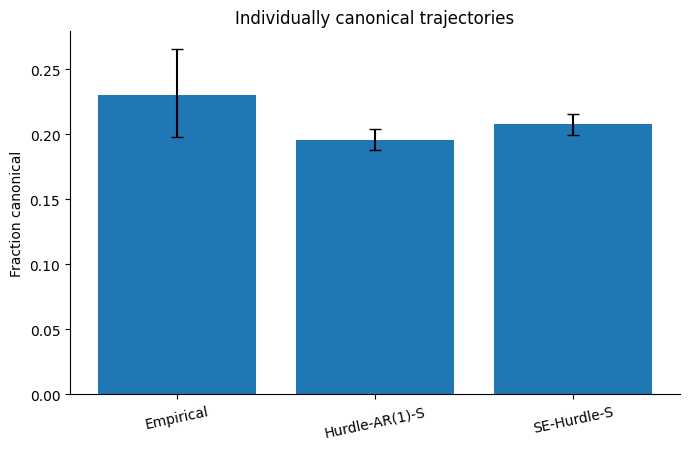

,model,n,canonical_n,canonical_fraction,ci_low,ci_high,median_changepoint
0,Empirical,591,136,0.230118,0.197992,0.265731,4.0
1,Hurdle-AR(1)-S,10000,1957,0.195700,0.188042,0.203592,4.0
2,SE-Hurdle-S,10000,2074,0.207400,0.199567,0.215458,4.0


In [165]:
def canonical_trajectories(q):
    n_years = q.shape[1]
    years = np.arange(n_years)

    X = np.column_stack([np.ones(n_years), years])
    coef = np.linalg.lstsq(X, q.T, rcond=None)[0]
    rss = np.sum((q.T - X @ coef) ** 2, axis=0)

    k = 3
    best_aicc = (
        n_years * np.log(np.maximum(rss, 1e-12) / n_years)
        + 2 * k
        + 2 * k * (k + 1) / (n_years - k - 1))

    best_cp = np.full(q.shape[0], -1)
    first_slope = coef[1].copy()
    second_slope = coef[1].copy()

    for cp in range(3, 18):
        X = np.column_stack([np.ones(n_years),years, np.maximum(0, years - cp)])

        coef = np.linalg.lstsq(X, q.T, rcond=None)[0]
        rss = np.sum((q.T - X @ coef) ** 2, axis=0)

        k = 4
        aicc = (n_years * np.log(np.maximum(rss, 1e-12) / n_years)+ 2 * k + 2 * k * (k + 1) / (n_years - k - 1))

        better = aicc < best_aicc
        best_aicc[better] = aicc[better]
        best_cp[better] = cp
        first_slope[better] = coef[1, better]
        second_slope[better] = coef[1, better] + coef[2, better]

    canonical = ((best_cp >= 0) & (first_slope > 0) & (second_slope < 0) & (np.abs(first_slope) >= 2 * np.abs(second_slope)))

    return canonical, best_cp, first_slope, second_slope

canonical_rows = []

for label, q in series:
    canonical, cp, first, second = canonical_trajectories(q)
    interval = stats.binomtest(
        canonical.sum(),
        len(canonical)).proportion_ci(method='wilson')

    canonical_rows.append({
        'model': label,
        'n': len(canonical),
        'canonical_n': canonical.sum(),
        'canonical_fraction': canonical.mean(),
        'ci_low': interval.low,
        'ci_high': interval.high,
        'median_changepoint': np.median(cp[canonical])})

canonical_summary = pd.DataFrame(canonical_rows)

fig, ax = plt.subplots(figsize=(7, 4.6))
x = np.arange(len(canonical_summary))
y = canonical_summary['canonical_fraction']
yerr = np.vstack([y - canonical_summary['ci_low'],canonical_summary['ci_high'] - y])

ax.bar(x, y, yerr=yerr, capsize=4)
ax.set(xticks=x,xticklabels=canonical_summary['model'],ylabel='Fraction canonical',title='Individually canonical trajectories')
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / 'canonical_trajectory_fraction.png', dpi=DPI, bbox_inches='tight')
plt.show()

canonical_summary.to_csv(
    RESULT_DIR / 'canonical_trajectory_fraction.csv',
    index=False)

canonical_summary

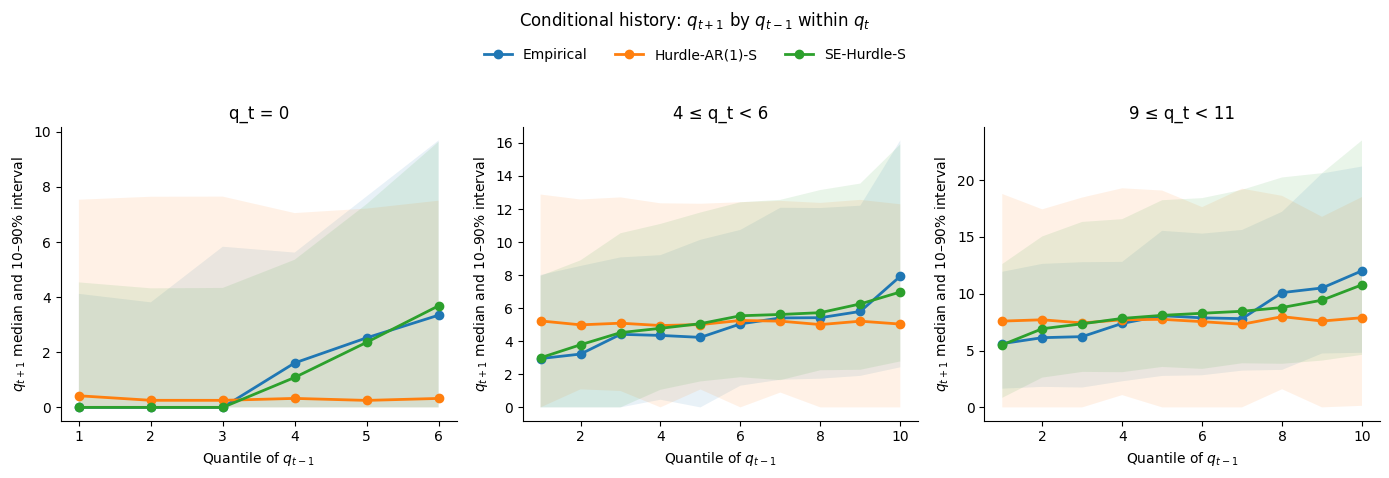

,prior_quantile,n,q_prev_mean,q_next_mean,q_next_median,zero_fraction,q10,q90,model,condition
0,1,318,0.000000,1.291803,0.000000,0.647799,0.000000,4.119417,Empirical,q_t = 0
1,2,317,0.000000,1.443792,0.000000,0.637224,0.000000,3.811037,Empirical,q_t = 0
2,3,317,0.051912,1.875955,0.000000,0.533123,0.000000,5.828729,Empirical,q_t = 0
3,4,317,1.907011,2.146061,1.612735,0.403785,0.000000,5.616423,Empirical,q_t = 0
4,5,317,3.345820,3.147970,2.524242,0.321767,0.000000,7.655431,Empirical,q_t = 0
...,...,...,...,...,...,...,...,...,...,...
73,6,1327,8.447047,9.852818,8.280047,0.027129,3.385310,18.407525,SE-Hurdle-S,9 ≤ q_t < 11
74,7,1328,9.936840,10.233433,8.455090,0.022590,3.879547,19.136490,SE-Hurdle-S,9 ≤ q_t < 11
75,8,1327,12.031283,10.779301,8.782888,0.027882,3.833667,20.226415,SE-Hurdle-S,9 ≤ q_t < 11
76,9,1328,15.268177,11.393904,9.431753,0.018825,4.116079,20.602480,SE-Hurdle-S,9 ≤ q_t < 11


In [166]:
HISTORY_SLICES = [
    ('q_t = 0', 0, 0, 6),
    ('4 ≤ q_t < 6', 4, 6, 10),
    ('9 ≤ q_t < 11', 9, 11, 10)]

def conditional_history_rows(q, label):
    q_prev = q[:, :-2].ravel()
    q_now = q[:, 1:-1].ravel()
    q_next = q[:, 2:].ravel()
    rows = []

    for slice_label, low, high, n_bins in HISTORY_SLICES:
        mask = q_now == 0 if high == 0 else (q_now >= low) & (q_now < high)
        d = pd.DataFrame({'q_prev': q_prev[mask], 'q_next': q_next[mask]})
        d['prior_quantile'] = (
            pd.qcut(d['q_prev'].rank(method='first'), n_bins, labels=False) + 1)

        grouped = d.groupby('prior_quantile')
        out = grouped.agg(n=('q_next', 'size'),
            q_prev_mean=('q_prev', 'mean'),q_next_mean=('q_next', 'mean'),
            q_next_median=('q_next', 'median'),
            zero_fraction=('q_next', lambda x: np.mean(x == 0))).reset_index()

        out['q10'] = grouped['q_next'].quantile(0.10).to_numpy()
        out['q90'] = grouped['q_next'].quantile(0.90).to_numpy()
        out['model'] = label
        out['condition'] = slice_label
        rows.append(out)

    return pd.concat(rows, ignore_index=True)

conditional_history = pd.concat([
    conditional_history_rows(q, label)
    for label, q in series],
    ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

for ax, (slice_label, _, _, _) in zip(axes, HISTORY_SLICES):
    stage_data = conditional_history[
        conditional_history['condition'].eq(slice_label)]

    for label, _ in series:
        d = stage_data[stage_data['model'].eq(label)]
        x = d['prior_quantile'].to_numpy()

        ax.plot(x,d['q_next_median'].to_numpy(),marker='o',linewidth=2,label=label)

        ax.fill_between(x,d['q10'].to_numpy(), d['q90'].to_numpy(),alpha=0.10)

    ax.set(title=slice_label,xlabel=r'Quantile of $q_{t-1}$',ylabel=r'$q_{t+1}$ median and 10–90% interval')
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,frameon=False)

fig.suptitle(r'Conditional history: $q_{t+1}$ by $q_{t-1}$ within $q_t$', y=1.10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'conditional_history_profiles.png', dpi=DPI, bbox_inches='tight')
plt.show()

conditional_history.to_csv(RESULT_DIR / 'conditional_history_profiles.csv',index=False)

conditional_history

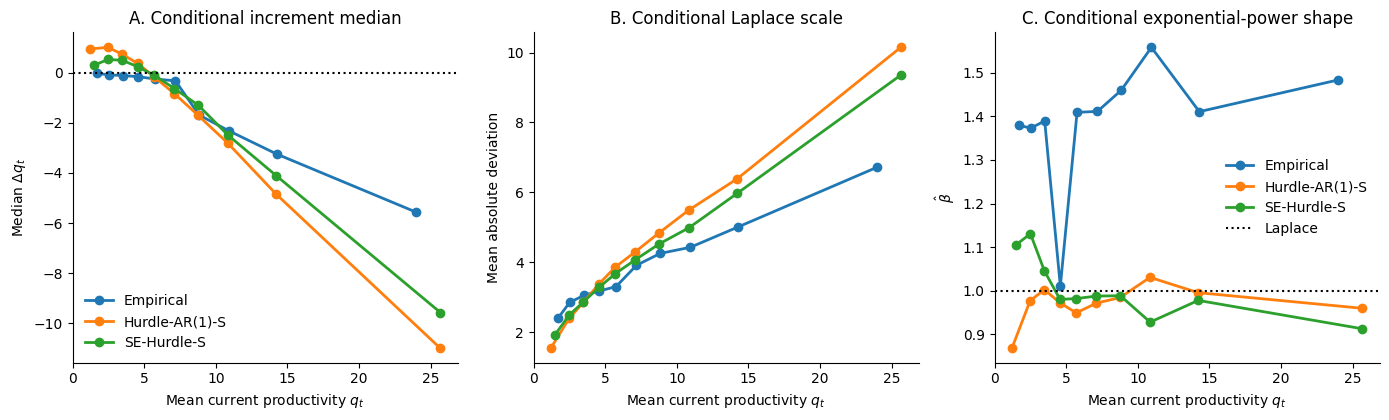

,model,q_bin,n,q_prev_mean,delta_median,laplace_scale,gennorm_beta,gennorm_loc,gennorm_scale
0,Empirical,1,980,1.686958,-0.035246,2.398284,1.379443,1.145491,3.400173
1,Empirical,2,993,2.512881,-0.085931,2.856437,1.372876,1.053031,4.121528
2,Empirical,3,942,3.492669,-0.118962,3.055494,1.389150,0.581618,4.441275
3,Empirical,4,977,4.584841,-0.161491,3.184766,1.010450,-0.161491,3.231497
4,Empirical,5,953,5.752838,-0.257792,3.308499,1.409041,-0.257343,4.812028
5,Empirical,6,1020,7.177652,-0.327227,3.917263,1.411216,-0.355143,5.679326
6,Empirical,7,932,8.835432,-1.693207,4.257425,1.459612,-1.011334,6.321353
7,Empirical,8,966,10.945642,-2.330372,4.432755,1.558072,-1.820334,6.892678
8,Empirical,9,958,14.291006,-3.256472,5.016323,1.410621,-2.978401,7.265227
9,Empirical,10,967,23.965328,-5.557219,6.717403,1.483204,-5.250004,10.080899


In [167]:
emp_prev = Q_EMP[:, :-1].ravel()
emp_prev = emp_prev[emp_prev > 0]

increment_edges = np.unique(np.quantile(np.log1p(emp_prev), np.linspace(0, 1, 11)))

increment_rows = []

for label, q in series:
    q_prev = q[:, :-1].ravel()
    delta = np.diff(q, axis=1).ravel()
    keep = q_prev > 0
    q_prev = q_prev[keep]
    delta = delta[keep]

    q_bin = (np.digitize(np.log1p(q_prev),increment_edges[1:-1],right=True)+ 1)

    for b in range(1, len(increment_edges)):
        values = delta[q_bin == b]
        mu = np.median(values)
        beta, loc, scale = stats.gennorm.fit(values)

        increment_rows.append({
            'model': label,
            'q_bin': b,
            'n': len(values),
            'q_prev_mean': q_prev[q_bin == b].mean(),
            'delta_median': mu,
            'laplace_scale': np.mean(np.abs(values - mu)),
            'gennorm_beta': beta,
            'gennorm_loc': loc,
            'gennorm_scale': scale})

increment_by_q = pd.DataFrame(increment_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

for label, _ in series:
    d = increment_by_q[increment_by_q['model'].eq(label)]

    axes[0].plot(d['q_prev_mean'],d['delta_median'],marker='o',linewidth=2,label=label)

    axes[1].plot(d['q_prev_mean'],d['laplace_scale'],marker='o',linewidth=2,label=label)

    axes[2].plot(d['q_prev_mean'],d['gennorm_beta'],marker='o',linewidth=2,label=label)

axes[0].axhline(0, linestyle=':', color='black')
axes[2].axhline(1, linestyle=':', color='black', label='Laplace')

axes[0].set(title='A. Conditional increment median', ylabel=r'Median $\Delta q_t$')
axes[1].set(title='B. Conditional Laplace scale', ylabel='Mean absolute deviation')
axes[2].set(title='C. Conditional exponential-power shape', ylabel=r'$\hat{\beta}$')

for ax in axes:
    #ax.set_xscale('log')
    ax.set_xlabel(r'Mean current productivity $q_t$')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(frameon=False)
axes[2].legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / 'increment_shape_by_productivity.png', dpi=DPI, bbox_inches='tight')
plt.show()

increment_by_q.to_csv(
    RESULT_DIR / 'increment_shape_by_productivity.csv',
    index=False)

increment_by_q

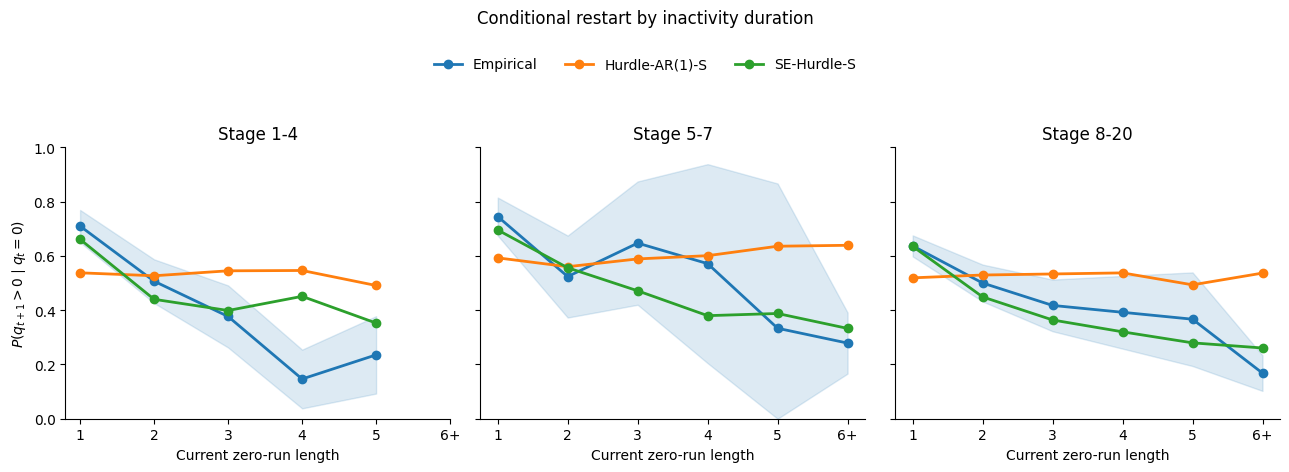

,model,stage,zero_run,restart_probability,n,se,low,high
0,Empirical,0,1,0.548246,228,0.032959,0.483646,0.612845
1,Empirical,1-4,1,0.709821,224,0.030324,0.650387,0.769256
2,Empirical,1-4,2,0.506757,148,0.041096,0.426209,0.587305
3,Empirical,1-4,3,0.376812,69,0.058337,0.262470,0.491153
4,Empirical,1-4,4,0.146341,41,0.055199,0.038151,0.254532
5,Empirical,1-4,5,0.235294,34,0.072747,0.092711,0.377878
6,Empirical,5-7,1,0.744966,149,0.035709,0.674977,0.814955
7,Empirical,5-7,2,0.523810,42,0.077064,0.372764,0.674855
8,Empirical,5-7,3,0.647059,17,0.115904,0.419887,0.874231
9,Empirical,5-7,4,0.571429,7,0.187044,0.204823,0.938035


In [168]:
def restart_spell_rows(q, label):
    rows = []
    run = np.zeros(q.shape[0], dtype=int)

    for t in range(Y):
        zero = q[:, t] == 0
        run = np.where(zero, run + 1, 0)
        idx = np.flatnonzero(zero)

        rows.append(pd.DataFrame({
            'model': label,
            'stage': transition_stage(t),
            'zero_run': np.minimum(run[idx], 6),
            'restart': (q[idx, t + 1] > 0).astype(int)}))

    return pd.concat(rows, ignore_index=True)

restart_data = pd.concat([
    restart_spell_rows(q, label)
    for label, q in series],
    ignore_index=True)

restart_summary = (restart_data.groupby(['model', 'stage', 'zero_run']).agg(restart_probability=('restart', 'mean'),n=('restart', 'size')).reset_index())

p = restart_summary['restart_probability']
restart_summary['se'] = np.sqrt(p * (1 - p) / restart_summary['n'])
restart_summary['low'] = (p - 1.96 * restart_summary['se']).clip(0, 1)
restart_summary['high'] = (p + 1.96 * restart_summary['se']).clip(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, stage in zip(axes, STAGE_ORDER[1:]):
    stage_data = restart_summary[restart_summary['stage'].eq(stage)]

    for label, _ in series:
        d = stage_data[stage_data['model'].eq(label)]

        line, = ax.plot(
            d['zero_run'],
            d['restart_probability'],
            marker='o',
            linewidth=2,
            label=label)

        if label == 'Empirical':
            ax.fill_between(d['zero_run'],d['low'], d['high'],alpha=0.15,color=line.get_color())

    ax.set(title=f'Stage {stage}',xlabel='Current zero-run length',ylim=(0, 1))
    ax.set_xticks(range(1, 7), ['1', '2', '3', '4', '5', '6+'])
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel(r'$P(q_{t+1}>0\mid q_t=0)$')
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False)

fig.suptitle('Conditional restart by inactivity duration', y=1.17)
fig.tight_layout()
fig.savefig(FIG_DIR / 'conditional_restart_by_zero_run.png', dpi=DPI, bbox_inches='tight')
plt.show()

restart_summary.to_csv(
    RESULT_DIR / 'conditional_restart_by_zero_run.csv',
    index=False)

restart_summary

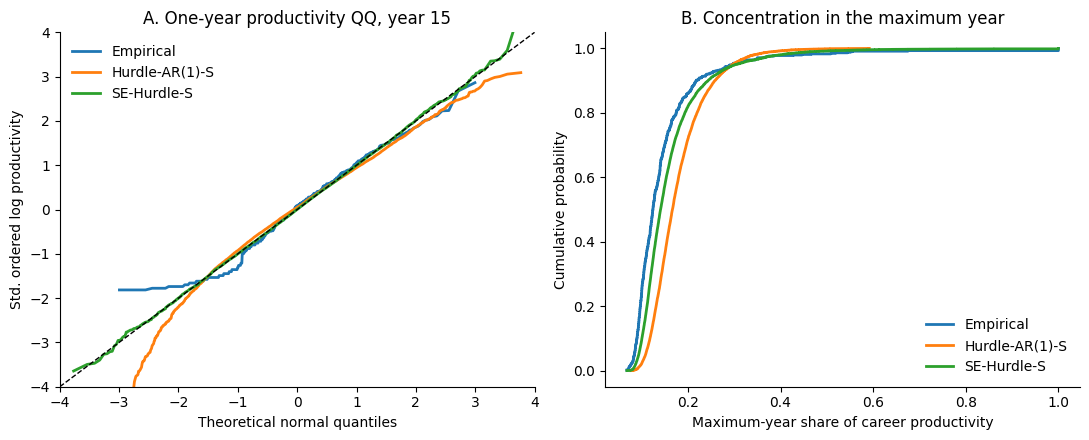

,model,year,annual_qq_r,annual_positive_n,max_share_mean,max_share_median,max_share_90
0,Empirical,15,0.990203,505,0.150283,0.124491,0.217882
1,Hurdle-AR(1)-S,15,0.990265,8419,0.179591,0.166603,0.257962
2,SE-Hurdle-S,15,0.999916,8380,0.162308,0.141002,0.243515


In [169]:
QQ_YEAR = 15
annual_qq_rows = []

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for label, q in series:
    details = qq_details(q[:, QQ_YEAR])

    axes[0].plot(
        details['theoretical'],
        details['ordered'],
        linewidth=2,
        label=label)

    total = q.sum(axis=1)
    share = q.max(axis=1)[total > 0] / total[total > 0]
    x, y = ecdf(share)

    axes[1].step(x,y, where='post',linewidth=2,label=label)

    annual_qq_rows.append({
        'model': label,
        'year': QQ_YEAR,
        'annual_qq_r': details['corr'],
        'annual_positive_n': details['n'],
        'max_share_mean': share.mean(),
        'max_share_median': np.median(share),
        'max_share_90': np.quantile(share, 0.90)})

axes[0].plot([-4, 4], [-4, 4], linestyle='--', linewidth=1, color='black')
axes[0].set(
    xlim=(-4, 4),ylim=(-4, 4),
    xlabel='Theoretical normal quantiles', ylabel='Std. ordered log productivity',title=f'A. One-year productivity QQ, year {QQ_YEAR}')

axes[1].set(xlabel='Maximum-year share of career productivity',ylabel='Cumulative probability',title='B. Concentration in the maximum year')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / 'annual_qq_and_max_share.png', dpi=DPI, bbox_inches='tight')
plt.show()

annual_qq_summary = pd.DataFrame(annual_qq_rows)
annual_qq_summary.to_csv( RESULT_DIR / 'annual_qq_and_max_share.csv',index=False)

annual_qq_summary

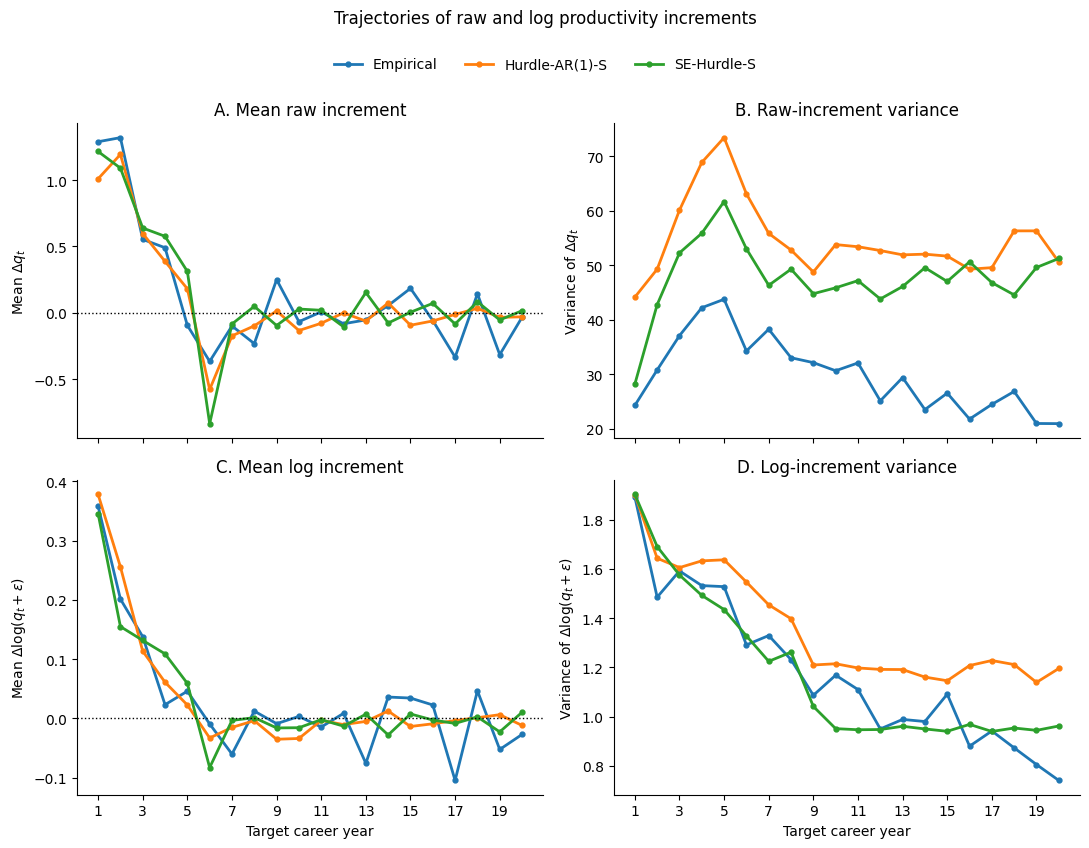

,model,transition_year,target_year,raw_delta_mean,raw_delta_variance,log_delta_mean,log_delta_variance
0,Empirical,0,1,1.288538,24.251117,0.358165,1.892563
1,Empirical,1,2,1.319432,30.759996,0.201241,1.485094
2,Empirical,2,3,0.552282,37.050817,0.137681,1.591738
3,Empirical,3,4,0.489587,42.179601,0.022935,1.532186
4,Empirical,4,5,-0.095565,43.725888,0.045733,1.527926
5,Empirical,5,6,-0.367253,34.245776,-0.009537,1.291134
6,Empirical,6,7,-0.100044,38.237702,-0.060435,1.329126
7,Empirical,7,8,-0.233472,33.001820,0.012100,1.231089
8,Empirical,8,9,0.249133,32.104527,-0.009064,1.086263
9,Empirical,9,10,-0.067735,30.615288,0.003085,1.167996


In [170]:
def delta_moment_stats(q, label):
    raw_delta = np.diff(q, axis=1)
    log_delta = np.diff(np.log(q + EPS), axis=1)

    return pd.DataFrame({
        'model': label,
        'transition_year': np.arange(Y),
        'target_year': np.arange(1, Y + 1),
        'raw_delta_mean': raw_delta.mean(axis=0),
        'raw_delta_variance': raw_delta.var(axis=0),
        'log_delta_mean': log_delta.mean(axis=0),
        'log_delta_variance': log_delta.var(axis=0)})


delta_stats = pd.concat([
    delta_moment_stats(Q_EMP, 'Empirical'),
    delta_moment_stats(Q_HURDLE, HURDLE_NAME),
    delta_moment_stats(Q_SELF, MODEL_NAME)],
    ignore_index=True)


metrics = [
    ('raw_delta_mean', r'A. Mean raw increment', r'Mean $\Delta q_t$'),
    ('raw_delta_variance', r'B. Raw-increment variance', r'Variance of $\Delta q_t$'),
    ('log_delta_mean', r'C. Mean log increment', r'Mean $\Delta \log(q_t+\epsilon)$'),
    ('log_delta_variance', r'D. Log-increment variance', r'Variance of $\Delta \log(q_t+\epsilon)$')]

fig, axes = plt.subplots(2,2,figsize=(11, 8),sharex=True)

for ax, (metric, title, ylabel) in zip(axes.ravel(), metrics):
    for label, group in delta_stats.groupby('model', sort=False):
        ax.plot(group['target_year'],group[metric],linewidth=2,marker='o',markersize=3.5,label=label)

    if metric.endswith('_mean'):
        ax.axhline(0,linestyle=':',linewidth=1,color='black')

    ax.set(title=title,ylabel=ylabel)

    ax.spines[['top', 'right']].set_visible(False)

for ax in axes[1]:
    ax.set_xlabel('Target career year')

axes[1, 0].set_xticks(np.arange(1, Y + 1, 2))
axes[1, 1].set_xticks(np.arange(1, Y + 1, 2))

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5, 1.01),ncol=3,frameon=False)

fig.suptitle('Trajectories of raw and log productivity increments',y=1.055)

fig.tight_layout()

fig.savefig(FIG_DIR / 'increment_moment_trajectories.png',dpi=DPI,bbox_inches='tight')

plt.show()

delta_stats.to_csv(RESULT_DIR / 'increment_moment_trajectories.csv',index=False)

delta_stats

In [171]:
rmse_metrics = [
    'raw_delta_mean',
    'raw_delta_variance',
    'log_delta_mean',
    'log_delta_variance']

empirical_stats = (delta_stats.loc[delta_stats['model'].eq('Empirical'),['target_year'] + rmse_metrics].set_index('target_year'))

rmse_rows = []

for model in [HURDLE_NAME, MODEL_NAME]:
    model_stats = (delta_stats.loc[delta_stats['model'].eq(model),['target_year'] + rmse_metrics].set_index('target_year').reindex(empirical_stats.index))

    rmse_rows.append({ 'model': model,**{metric: np.sqrt(np.mean((model_stats[metric] - empirical_stats[metric]) ** 2)) for metric in rmse_metrics}})

rmse_summary = pd.DataFrame(rmse_rows).rename(columns={
    'raw_delta_mean': 'RMSE: raw delta mean',
    'raw_delta_variance': 'RMSE: raw delta variance',
    'log_delta_mean': 'RMSE: log delta mean',
    'log_delta_variance': 'RMSE: log delta variance'})

print('\nIncrement-moment trajectory RMSE against empirical\n')
print(rmse_summary.to_string(
    index=False,
    float_format=lambda x: f'{x:.6f}'))

rmse_summary.to_csv(
    RESULT_DIR / 'increment_moment_rmse.csv',
    index=False)


Increment-moment trajectory RMSE against empirical

         model  RMSE: raw delta mean  RMSE: raw delta variance  RMSE: log delta mean  RMSE: log delta variance
Hurdle-AR(1)-S              0.172832                 25.246342              0.042502                  0.216698
   SE-Hurdle-S              0.213673                 19.111326              0.047713                  0.111661
